# Evaluate File

## 0 Import Packages

In [1]:
# import cell
from pathlib import Path
from collections.abc import Sequence
import csv
import math
import re

import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
import numpy as np
from PIL import Image

## 1 Preprocessing

- read images and masks, and save to the list `images` and `masks`.
- preprocessing the images, apply the masks to the images and save to the list `images_masked`.
- normalization, and save to the list `images_normalized`.

### 1.1 Read images and masks

In [2]:
def natural_key(path: str | Path) -> list[int | str]:
    """Sort file names by their numeric image id instead of pure text order."""
    name = Path(path).stem
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", name)]


def find_data_dir(data_dir: str | Path | None = None) -> Path:
    """Find the folder that contains image/, mask/, and label.csv."""
    if data_dir is not None:
        return Path(data_dir)

    candidates = [Path.cwd(), Path.cwd() / "project2" / "Data_Proj2"]
    for candidate in candidates:
        if (candidate / "image").is_dir() and (candidate / "mask").is_dir():
            return candidate
    raise FileNotFoundError("Cannot find image/ and mask/ folders. Run this notebook from Data_Proj2 or the repository root.")


def read_images_and_masks(data_dir: str | Path | None = None, image_size: tuple[int, int] = (224, 224)) -> tuple[list[str], list[np.ndarray], list[np.ndarray]]:
    """Read all images and their matching masks.

    Returns
    -------
    image_ids : list[str]
        File stems such as "1", "1_aug1".
    images : list[np.ndarray]
        RGB images as uint8 arrays with shape (H, W, 3).
    masks : list[np.ndarray]
        Binary masks as bool arrays with shape (H, W).
    """
    data_dir = find_data_dir(data_dir)
    image_dir = data_dir / "image_processed"
    mask_dir = data_dir / "mask"

    image_paths = sorted(image_dir.glob("*.jpg"), key=natural_key)
    image_ids: list[str] = []
    images: list[np.ndarray] = []
    masks: list[np.ndarray] = []

    for image_path in image_paths:
        image_id = image_path.stem
        mask_path = mask_dir / f"mask_{image_id}.jpg"
        if not mask_path.exists():
            raise FileNotFoundError(f"Missing mask for {image_path.name}: {mask_path}")

        image = Image.open(image_path).convert("RGB").resize(image_size)
        mask = Image.open(mask_path).convert("L").resize(image_size)

        image_ids.append(image_id)
        images.append(np.asarray(image, dtype=np.uint8))
        masks.append(np.asarray(mask) > 127)

    return image_ids, images, masks

### 1.2 Preprocessing images and masks

In [3]:
def apply_masks(images: Sequence[np.ndarray], masks: Sequence[np.ndarray], background_value: int = 0) -> list[np.ndarray]:
    """Keep only the lesion area and set the background to background_value."""
    images_masked: list[np.ndarray] = []
    for image, mask in zip(images, masks):
        masked = np.full_like(image, background_value)
        masked[mask] = image[mask]
        images_masked.append(masked)
    return images_masked

### 1.3 Normalization

In [4]:
def normalize_images(images_masked: Sequence[np.ndarray], masks: Sequence[np.ndarray], eps: float = 1e-6) -> tuple[list[np.ndarray], dict[str, np.ndarray]]:
    """Dataset-level z-score normalization using lesion pixels only.

    Background pixels are kept at 0 after normalization so later feature
    extraction can focus on the masked lesion region.
    """
    lesion_pixels = np.concatenate([
        image[mask].astype(np.float32) / 255.0
        for image, mask in zip(images_masked, masks)
        if np.any(mask)
    ])
    mean = lesion_pixels.mean(axis=0)
    std = lesion_pixels.std(axis=0) + eps

    images_normalized: list[np.ndarray] = []
    for image, mask in zip(images_masked, masks):
        normalized = np.zeros(image.shape, dtype=np.float32)
        normalized[mask] = (image[mask].astype(np.float32) / 255.0 - mean) / std
        images_normalized.append(normalized)

    return images_normalized, {"mean": mean, "std": std}


def denormalize_for_display(image_normalized: np.ndarray, mask: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """Convert one normalized image back to RGB range for visualization."""
    display = np.zeros_like(image_normalized, dtype=np.float32)
    if np.any(mask):
        display[mask] = image_normalized[mask] * std + mean
    display = np.clip(display, 0, 1)
    return display

### 1.4 Test

In [5]:
data_dir = find_data_dir()
image_ids, images, masks = read_images_and_masks(data_dir)
images_masked = apply_masks(images, masks)
images_normalized, normalization_stats = normalize_images(images_masked, masks)

print(f"Loaded {len(images)} images and {len(masks)} masks from {data_dir}")
print("First image id:", image_ids[0])
print("Image shape:", images[0].shape)
print("RGB lesion mean:", normalization_stats["mean"])
print("RGB lesion std:", normalization_stats["std"])

Loaded 600 images and 600 masks from /mnt/d/AppData/Python/BIP/project2/Data_Proj2
First image id: 1
Image shape: (224, 224, 3)
RGB lesion mean: [0.6339394  0.5246055  0.49973148]
RGB lesion std: [0.15946701 0.20535561 0.20678791]


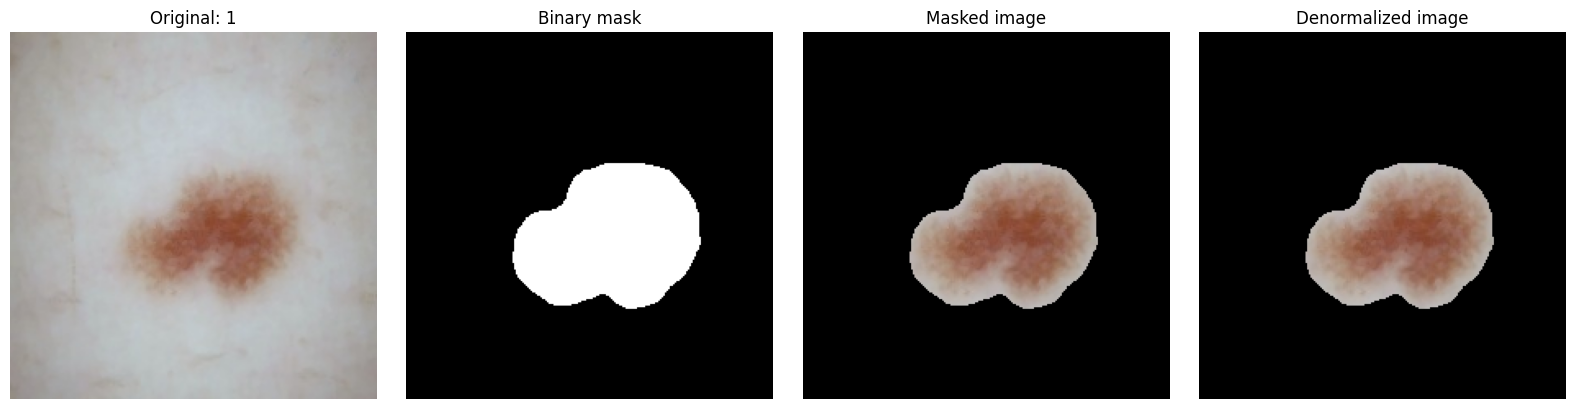

In [6]:
# test: show one image of every step
idx = 0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(images[idx])
axes[0].set_title(f"Original: {image_ids[idx]}")

axes[1].imshow(masks[idx], cmap="gray")
axes[1].set_title("Binary mask")

axes[2].imshow(images_masked[idx])
axes[2].set_title("Masked image")

axes[3].imshow(denormalize_for_display(
    images_normalized[idx],
    masks[idx],
    normalization_stats["mean"],
    normalization_stats["std"],
))
axes[3].set_title("Denormalized image")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2 Feature Analysis

In this part, feature values are extracted from each masked lesion image. 
The next step will compare the discriminative ability of individual features.

### 2.0 Read the label

- read the label.csv and save to the list `label`.

In [7]:
# funtion to read the label.csv file
def read_labels(data_dir: str | Path | None = None, image_ids_to_align: Sequence[str] | None = None) -> tuple[list[str], dict[str, str]]:
    """Read label.csv and return labels aligned with image_ids."""
    data_dir = find_data_dir(data_dir)
    image_ids_to_align = image_ids if image_ids_to_align is None else image_ids_to_align
    label_path = data_dir / "label.csv"
    label_by_id: dict[str, str] = {}

    with label_path.open(newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        for row in reader:
            label_by_id[str(row["image_id"])] = row["dx"]

    missing = [image_id for image_id in image_ids_to_align if image_id not in label_by_id]
    if missing:
        raise ValueError(f"Missing labels for {len(missing)} images, for example: {missing[:5]}")

    return [label_by_id[image_id] for image_id in image_ids_to_align], label_by_id


labels, label_by_id = read_labels(data_dir, image_ids)
label = labels
print(f"Loaded {len(labels)} labels")
print("Label classes:", sorted(set(labels)))

Loaded 600 labels
Label classes: ['mel', 'nv', 'vasc']


### 2.1 Feature extraction

#### basic functions for feature extraction

In [8]:
# basic functions for feature extraction
def get_lesion_rgb_pixels(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Return lesion RGB pixels in [0, 1]."""
    image_float = image.astype(np.float32) / 255.0
    pixels = image_float[mask]
    if pixels.size == 0:
        pixels = image_float.reshape(-1, 3)
    return pixels


def summarize_channels(
    channel_data: np.ndarray,
    channel_names: tuple[str, ...],
    stats: tuple[str, ...] = ("mean", "std", "p10", "p50", "p90"),
) -> tuple[list[float], list[str]]:
    """Summarize one image and return a feature row plus feature names."""
    values: list[float] = []
    names: list[str] = []

    for channel_name, channel_values in zip(channel_names, channel_data.T):
        for stat in stats:
            names.append(f"{channel_name}_{stat}")
            if stat == "mean":
                values.append(float(channel_values.mean()))
            elif stat == "std":
                values.append(float(channel_values.std()))
            elif stat.startswith("p"):
                values.append(float(np.percentile(channel_values, float(stat[1:]))))
            else:
                raise ValueError(f"Unsupported stat: {stat}")

    return values, names


# basic functions for geometric feature extraction
def mask_perimeter(mask: np.ndarray) -> float:
    """Estimate mask perimeter with horizontal and vertical edge transitions."""
    padded = np.pad(mask.astype(np.int16), pad_width=1, mode="constant", constant_values=0)
    vertical_edges = np.abs(np.diff(padded, axis=0)).sum()
    horizontal_edges = np.abs(np.diff(padded, axis=1)).sum()
    return float(vertical_edges + horizontal_edges)


def convex_hull(points: np.ndarray) -> list[tuple[float, float]]:
    """Compute a 2D convex hull with the monotonic chain algorithm."""
    if len(points) <= 1:
        return [tuple(point) for point in points]

    sorted_points = sorted({(float(x), float(y)) for x, y in points})
    if len(sorted_points) <= 1:
        return sorted_points

    def cross(origin: tuple[float, float], a: tuple[float, float], b: tuple[float, float]) -> float:
        return (a[0] - origin[0]) * (b[1] - origin[1]) - (a[1] - origin[1]) * (b[0] - origin[0])

    lower: list[tuple[float, float]] = []
    for point in sorted_points:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], point) <= 0:
            lower.pop()
        lower.append(point)

    upper: list[tuple[float, float]] = []
    for point in reversed(sorted_points):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], point) <= 0:
            upper.pop()
        upper.append(point)

    return lower[:-1] + upper[:-1]


def polygon_area(points: Sequence[tuple[float, float]]) -> float:
    """Compute polygon area with the shoelace formula."""
    if len(points) < 3:
        return 0.0
    x = np.asarray([point[0] for point in points], dtype=np.float32)
    y = np.asarray([point[1] for point in points], dtype=np.float32)
    return float(0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))


# functions for texture feature extraction
def quantize_gray_image(image: np.ndarray, levels: int = 16) -> np.ndarray:
    """Convert an RGB image to quantized grayscale levels."""
    image_float = image.astype(np.float32) / 255.0
    gray = image_float.mean(axis=2)
    return np.clip((gray * levels).astype(np.int32), 0, levels - 1)


def compute_glcm_features(
        image: np.ndarray,
        mask: np.ndarray,
        levels: int = 16,
        offsets: tuple[tuple[int, int], ...] = ((0, 1), (1, 0), (1, 1), (-1, 1)),
        eps: float = 1e-8,
    ) -> list[float]:
    """Compute averaged GLCM contrast, correlation, energy, and homogeneity."""
    quantized = quantize_gray_image(image, levels=levels)
    glcm = np.zeros((levels, levels), dtype=np.float64)
    rows, cols = quantized.shape

    for dr, dc in offsets:
        row_start = max(0, -dr)
        row_end = min(rows, rows - dr)
        col_start = max(0, -dc)
        col_end = min(cols, cols - dc)
        source_mask = mask[row_start:row_end, col_start:col_end]
        target_mask = mask[row_start + dr:row_end + dr, col_start + dc:col_end + dc]
        valid = source_mask & target_mask
        if not np.any(valid):
            continue
        source_values = quantized[row_start:row_end, col_start:col_end][valid]
        target_values = quantized[row_start + dr:row_end + dr, col_start + dc:col_end + dc][valid]
        np.add.at(glcm, (source_values, target_values), 1)
        np.add.at(glcm, (target_values, source_values), 1)

    if glcm.sum() == 0:
        return [0.0, 0.0, 0.0, 0.0]

    probability = glcm / glcm.sum()
    i, j = np.indices((levels, levels))
    contrast = float(np.sum(((i - j) ** 2) * probability))
    mean_i = float(np.sum(i * probability))
    mean_j = float(np.sum(j * probability))
    std_i = float(np.sqrt(np.sum(((i - mean_i) ** 2) * probability)))
    std_j = float(np.sqrt(np.sum(((j - mean_j) ** 2) * probability)))
    correlation = float(np.sum((i - mean_i) * (j - mean_j) * probability) / (std_i * std_j + eps))
    energy = float(np.sqrt(np.sum(probability ** 2)))
    homogeneity = float(np.sum(probability / (1.0 + np.abs(i - j))))
    return [contrast, correlation, energy, homogeneity]


def compute_lbp_histogram(image: np.ndarray, mask: np.ndarray, bins: int = 16) -> list[float]:
    """Compute a fixed-length Local Binary Pattern histogram inside the mask."""
    image_float = image.astype(np.float32) / 255.0
    gray = image_float.mean(axis=2)
    padded_gray = np.pad(gray, pad_width=1, mode="edge")
    padded_mask = np.pad(mask, pad_width=1, mode="constant", constant_values=False)
    center = padded_gray[1:-1, 1:-1]
    valid = padded_mask[1:-1, 1:-1]

    codes = np.zeros_like(center, dtype=np.uint8)
    neighbor_offsets = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, 1), (1, 1), (1, 0),
        (1, -1), (0, -1),
    ]
    for bit, (dr, dc) in enumerate(neighbor_offsets):
        neighbor = padded_gray[1 + dr:center.shape[0] + 1 + dr, 1 + dc:center.shape[1] + 1 + dc]
        codes |= ((neighbor >= center).astype(np.uint8) << bit)

    selected_codes = codes[valid]
    if selected_codes.size == 0:
        return [0.0] * bins
    hist, _ = np.histogram(selected_codes, bins=bins, range=(0, 256), density=False)
    hist = hist.astype(np.float32) / max(hist.sum(), 1)
    return hist.tolist()

#### functions to extract features from lesion pixels

In [9]:
# functions to extract features from lesion pixels
def extract_lesion_feature_rgb(
        images: Sequence[np.ndarray], 
        masks: Sequence[np.ndarray]
    ) -> tuple[np.ndarray, list[str]]:
    """Extract RGB channel statistics from lesion pixels."""
    feature_rows: list[list[float]] = []
    feature_names: list[str] | None = None

    for image, mask in zip(images, masks):
        rgb_pixels = get_lesion_rgb_pixels(image, mask)
        row, names = summarize_channels(
            rgb_pixels,
            channel_names=("rgb_r", "rgb_g", "rgb_b"),
            stats=("mean", "std", "p10", "p50", "p90"),
        )
        feature_rows.append(row)
        if feature_names is None:
            feature_names = names

    return np.asarray(feature_rows, dtype=np.float32), feature_names or []


def extract_lesion_feature_hsv(
        images: Sequence[np.ndarray], 
        masks: Sequence[np.ndarray]
    ) -> tuple[np.ndarray, list[str]]:
    """Extract HSV channel statistics from lesion pixels."""
    feature_rows: list[list[float]] = []
    feature_names: list[str] | None = None

    for image, mask in zip(images, masks):
        rgb_pixels = get_lesion_rgb_pixels(image, mask)
        hsv_pixels = rgb_to_hsv(rgb_pixels.reshape(-1, 1, 3)).reshape(-1, 3)
        row, names = summarize_channels(
            hsv_pixels,
            channel_names=("hsv_h", "hsv_s", "hsv_v"),
            stats=("mean", "std", "p50"),
        )
        feature_rows.append(row)
        if feature_names is None:
            feature_names = names

    return np.asarray(feature_rows, dtype=np.float32), feature_names or []


# Strength Characteristics
# Mean, Variance, Skewness, Kurtosis, Energy, Entropy
def extract_lesion_feature_gray(
        images: Sequence[np.ndarray], 
        masks: Sequence[np.ndarray],
        histogram_bins: int = 32,
        eps: float = 1e-8,
    ) -> tuple[np.ndarray, list[str]]:
    """Extract grayscale intensity and distribution features from lesion pixels."""
    feature_rows: list[list[float]] = []
    feature_names = [
        "gray_mean",
        "gray_std",
        "gray_variance",
        "gray_skewness",
        "gray_kurtosis",
        "gray_energy",
        "gray_entropy",
        "gray_p10",
        "gray_p90",
    ]

    for image, mask in zip(images, masks):
        rgb_pixels = get_lesion_rgb_pixels(image, mask)
        gray_pixels = rgb_pixels.mean(axis=1)
        mean = float(gray_pixels.mean())
        std = float(gray_pixels.std())
        variance = float(gray_pixels.var())
        centered = gray_pixels - mean
        skewness = float(np.mean((centered / (std + eps)) ** 3))
        kurtosis = float(np.mean((centered / (std + eps)) ** 4))
        hist, _ = np.histogram(gray_pixels, bins=histogram_bins, range=(0.0, 1.0), density=False)
        prob = hist.astype(np.float32) / max(hist.sum(), 1)
        prob_nonzero = prob[prob > 0]
        energy = float(np.sum(prob ** 2))
        entropy = float(-np.sum(prob_nonzero * np.log2(prob_nonzero)))
        p10 = float(np.percentile(gray_pixels, 10))
        p90 = float(np.percentile(gray_pixels, 90))
        feature_rows.append([mean, std, variance, skewness, kurtosis, energy, entropy, p10, p90])

    return np.asarray(feature_rows, dtype=np.float32), feature_names or []


# Geometry Features
# Area, Perimeter, Equivalent Diameter, Major/Minor Axis Lengths, Eccentricity, Ellipticity, Convex Hull Area, Solidity
def extract_lesion_feature_geometry(
        images: Sequence[np.ndarray], 
        masks: Sequence[np.ndarray],
        eps: float = 1e-8,
    ) -> tuple[np.ndarray, list[str]]:
    """Extract geometry features from lesion masks."""
    feature_rows: list[list[float]] = []
    feature_names = [
        "geometry_area",
        "geometry_perimeter",
        "geometry_equivalent_diameter",
        "geometry_major_axis_length",
        "geometry_minor_axis_length",
        "geometry_eccentricity",
        "geometry_ellipticity",
        "geometry_convex_hull_area",
        "geometry_solidity",
    ]

    for mask in masks:
        rows, cols = np.where(mask)
        area = float(mask.sum())
        perimeter = mask_perimeter(mask)
        equivalent_diameter = float(np.sqrt(4.0 * area / np.pi)) if area > 0 else 0.0

        if len(rows) >= 2:
            coords = np.column_stack([cols.astype(np.float32), rows.astype(np.float32)])
            covariance = np.cov(coords, rowvar=False)
            eigenvalues = np.linalg.eigvalsh(covariance)
            eigenvalues = np.maximum(np.sort(eigenvalues)[::-1], 0.0)
            major_axis_length = float(4.0 * np.sqrt(eigenvalues[0]))
            minor_axis_length = float(4.0 * np.sqrt(eigenvalues[1])) if len(eigenvalues) > 1 else 0.0
            eccentricity = float(np.sqrt(max(0.0, 1.0 - (minor_axis_length ** 2) / (major_axis_length ** 2 + eps))))
            ellipticity = float(major_axis_length / (minor_axis_length + eps))
            hull_points = convex_hull(coords)
            convex_hull_area = max(polygon_area(hull_points), area)
        else:
            major_axis_length = 0.0
            minor_axis_length = 0.0
            eccentricity = 0.0
            ellipticity = 0.0
            convex_hull_area = area

        solidity = float(area / (convex_hull_area + eps)) if convex_hull_area > 0 else 0.0
        feature_rows.append([
            area,
            perimeter,
            equivalent_diameter,
            major_axis_length,
            minor_axis_length,
            eccentricity,
            ellipticity,
            convex_hull_area,
            solidity,
        ])

    return np.asarray(feature_rows, dtype=np.float32), feature_names or []


# Texture Features
# Gray-Level Co-occurrence Matrix (GLCM): contrast, correlation, energy, and homogeneity
# Local Binary Patterns (LBP): fixed-length histograms
def extract_lesion_feature_texture(
        images: Sequence[np.ndarray], 
        masks: Sequence[np.ndarray],
        glcm_levels: int = 16,
        lbp_bins: int = 16,
    ) -> tuple[np.ndarray, list[str]]:
    """Extract GLCM and LBP texture features from lesion pixels."""
    feature_rows: list[list[float]] = []
    feature_names = [
        "texture_glcm_contrast",
        "texture_glcm_correlation",
        "texture_glcm_energy",
        "texture_glcm_homogeneity",
    ] + [f"texture_lbp_bin_{idx:02d}" for idx in range(lbp_bins)]

    for image, mask in zip(images, masks):
        glcm_features = compute_glcm_features(image, mask, levels=glcm_levels)
        lbp_features = compute_lbp_histogram(image, mask, bins=lbp_bins)
        feature_rows.append(glcm_features + lbp_features)

    return np.asarray(feature_rows, dtype=np.float32), feature_names or []


#### fucntions to concat features

In [10]:
# fucntions to concat features
def concat_features(*feature_matrices: np.ndarray | Sequence[np.ndarray]) -> np.ndarray:
    """Concatenate feature matrices by columns."""
    if len(feature_matrices) == 1 and isinstance(feature_matrices[0], (list, tuple)):
        feature_matrices = tuple(feature_matrices[0])
    return np.concatenate(feature_matrices, axis=1)


def concat_feature_names(*feature_name_lists: Sequence[str] | Sequence[Sequence[str]]) -> list[str]:
    """Concatenate feature-name lists while preserving order."""
    if len(feature_name_lists) == 1 and isinstance(feature_name_lists[0], (list, tuple)):
        feature_name_lists = tuple(feature_name_lists[0])

    names: list[str] = []
    for feature_name_list in feature_name_lists:
        names.extend(feature_name_list)
    return names


def concat_freature_names(*feature_name_lists: Sequence[str] | Sequence[Sequence[str]]) -> list[str]:
    """Backward-compatible alias for concat_feature_names."""
    return concat_feature_names(*feature_name_lists)

#### function to simplify

In [11]:
def extract_lesion_features(images: Sequence[np.ndarray], masks: Sequence[np.ndarray]) -> tuple[np.ndarray, list[str]]:
    """Combine the currently selected lesion feature groups."""
    rgb_features, rgb_feature_names = extract_lesion_feature_rgb(images, masks)
    hsv_features, hsv_feature_names = extract_lesion_feature_hsv(images, masks)
    gray_features, gray_feature_names = extract_lesion_feature_gray(images, masks)
    geometry_features, geometry_feature_names = extract_lesion_feature_geometry(images, masks)
    texture_features, texture_feature_names = extract_lesion_feature_texture(images, masks)

    features = concat_features(
        rgb_features,
        hsv_features,
        gray_features,
        geometry_features,
        texture_features,
    )
    feature_names = concat_feature_names(
        rgb_feature_names,
        hsv_feature_names,
        gray_feature_names,
        geometry_feature_names,
        texture_feature_names,
    )
    return features, feature_names


def standardize_features(features: np.ndarray, eps: float = 1e-6) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Standardize feature columns for later feature comparison or modeling."""
    mean = features.mean(axis=0)
    std = features.std(axis=0) + eps
    return (features - mean) / std, {"mean": mean, "std": std}


#### Test

In [12]:
# test cell
rgb_features, rgb_feature_names = extract_lesion_feature_rgb(images, masks)
hsv_features, hsv_feature_names = extract_lesion_feature_hsv(images, masks)
gray_features, gray_feature_names = extract_lesion_feature_gray(images, masks)
geometry_features, geometry_feature_names = extract_lesion_feature_geometry(images, masks)
texture_features, texture_feature_names = extract_lesion_feature_texture(images, masks)

features = concat_features(
    rgb_features,
    hsv_features,
    gray_features,
    geometry_features,
    texture_features,
)
feature_names = concat_feature_names(
    rgb_feature_names,
    hsv_feature_names,
    gray_feature_names,
    geometry_feature_names,
    texture_feature_names,
)
features_scaled, feature_scaler = standardize_features(features)

print(f"RGB feature matrix shape: {rgb_features.shape}")
print(f"HSV feature matrix shape: {hsv_features.shape}")
print(f"Gray feature matrix shape: {gray_features.shape}")
print(f"Geometry feature matrix shape: {geometry_features.shape}")
print(f"Texture feature matrix shape: {texture_features.shape}")
print(f"Combined feature matrix shape: {features.shape}")
print(f"Number of features: {len(feature_names)}")


RGB feature matrix shape: (600, 15)
HSV feature matrix shape: (600, 9)
Gray feature matrix shape: (600, 9)
Geometry feature matrix shape: (600, 9)
Texture feature matrix shape: (600, 20)
Combined feature matrix shape: (600, 62)
Number of features: 62


### 2.2 Visualization

- show the rgb image: x axis is the feature value of every image, with the point color is the label of the image.

In [13]:
# function to visualize feature distributions by label class
def plot_feature_distribution_by_label(
    features: np.ndarray,
    feature_names: Sequence[str],
    labels: Sequence[str],
    selected_features: Sequence[str] | None = None,
    label_order: tuple[str, ...] = ("mel", "nv", "vasc"),
    colors: dict[str, str] | None = None,
    n_cols: int = 3,
    jitter: float = 0.08,
    point_size: int = 22,
    alpha: float = 0.75,
    random_state: int = 42,
    title: str = "Feature distribution by label",
) -> None:
    """Plot selected feature values on the x-axis with point color showing labels."""
    labels_array = np.asarray(labels)
    colors = {"mel": "tab:red", "nv": "tab:blue", "vasc": "tab:green"} if colors is None else colors
    selected_features = list(feature_names) if selected_features is None else list(selected_features)
    feature_index = {feature_name: idx for idx, feature_name in enumerate(feature_names)}
    missing_features = [feature_name for feature_name in selected_features if feature_name not in feature_index]
    if missing_features:
        raise ValueError(f"Unknown selected features: {missing_features}")

    n_features = len(selected_features)
    n_rows = math.ceil(n_features / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 2.8 * n_rows), squeeze=False)
    rng = np.random.default_rng(random_state)
    label_to_y = {label_name: idx for idx, label_name in enumerate(label_order)}

    for ax, feature_name in zip(axes.ravel(), selected_features):
        values = features[:, feature_index[feature_name]]
        for label_name in label_order:
            idx = labels_array == label_name
            if not np.any(idx):
                continue
            y = np.full(idx.sum(), label_to_y[label_name], dtype=np.float32)
            y += rng.normal(0, jitter, size=idx.sum())
            ax.scatter(values[idx], y, color=colors.get(label_name, "gray"), s=point_size, alpha=alpha, label=label_name, edgecolors="none")

        ax.set_title(feature_name)
        ax.set_yticks(list(label_to_y.values()), list(label_to_y.keys()))
        ax.grid(axis="x", alpha=0.25)

    for ax in axes.ravel()[n_features:]:
        ax.axis("off")

    handles, legend_labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, title="dx", loc="upper right")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

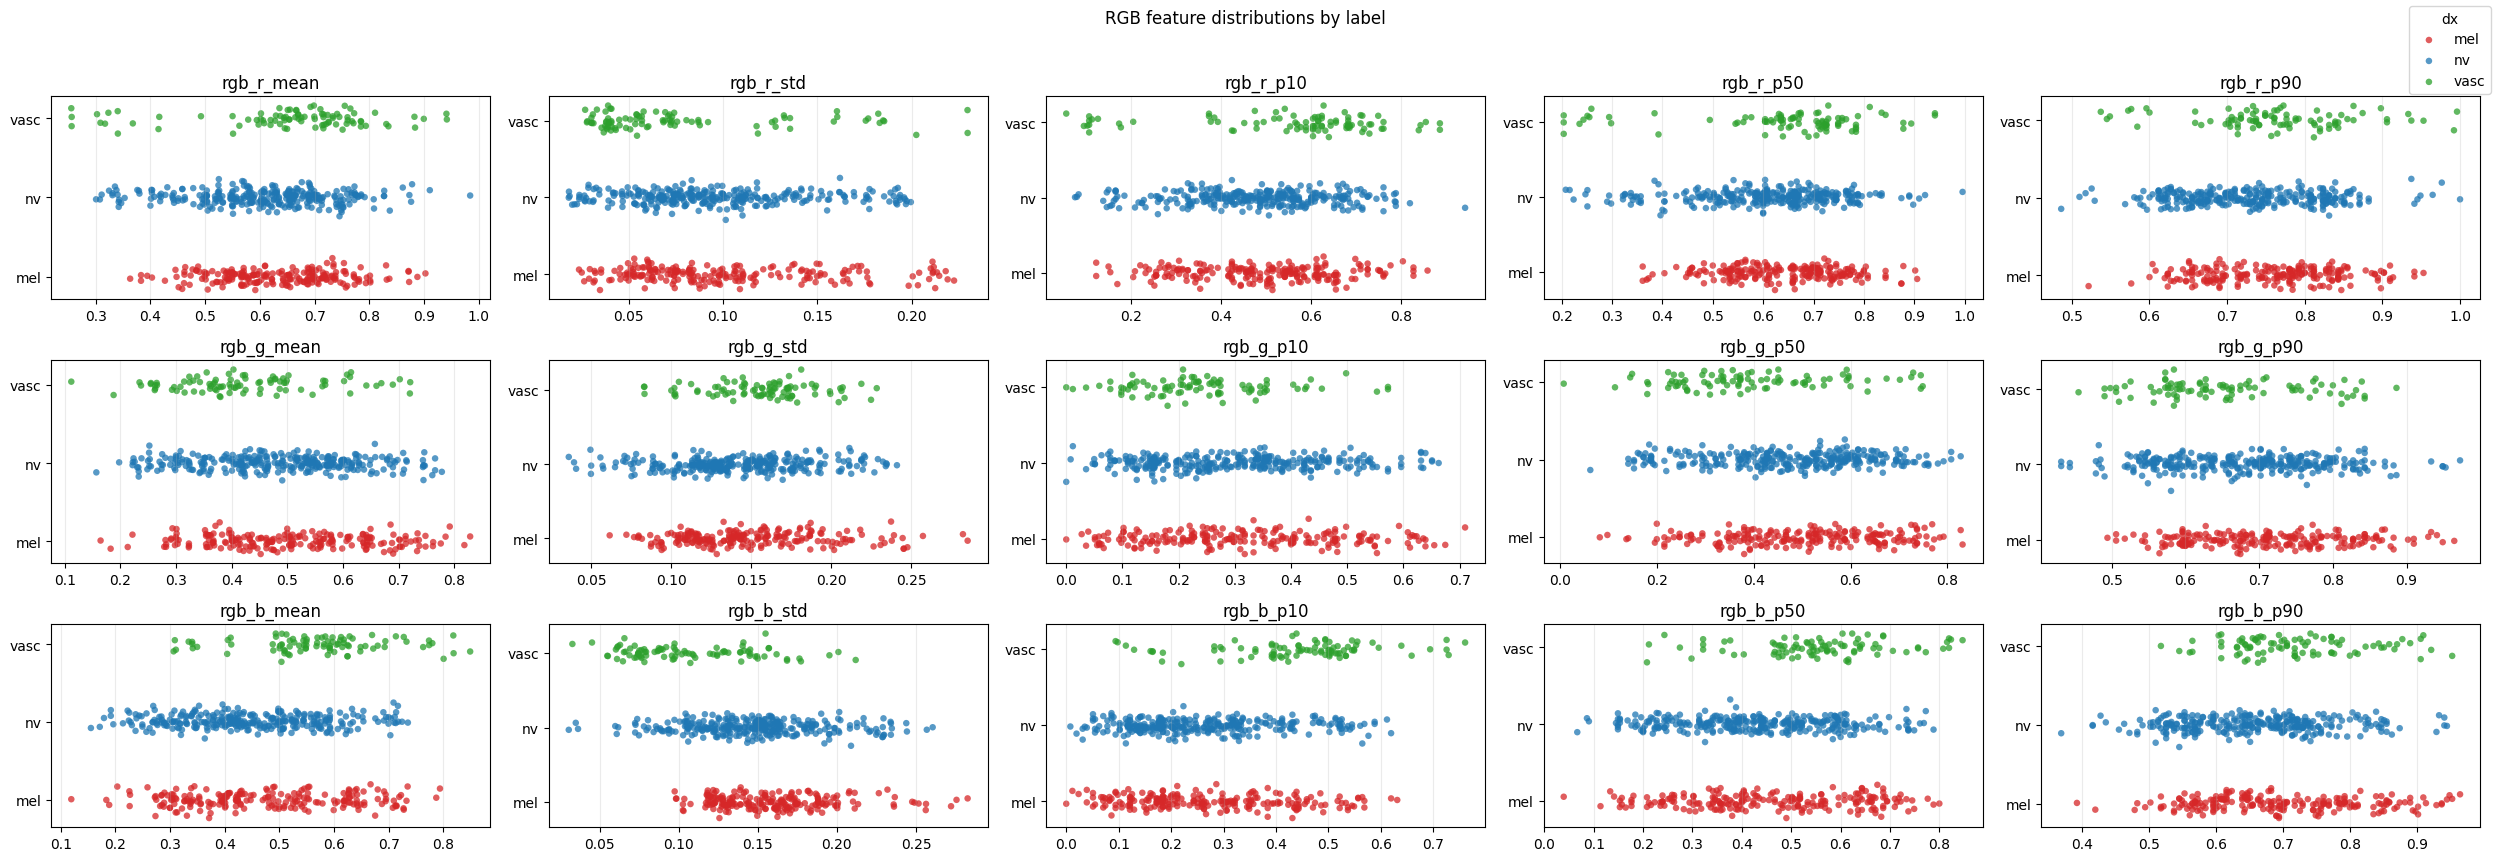

In [14]:
# test cell: rgb feature distributions by label
plot_feature_distribution_by_label(
    rgb_features,
    rgb_feature_names,
    labels,
    selected_features=rgb_feature_names,
    n_cols=5,
    title="RGB feature distributions by label",
)

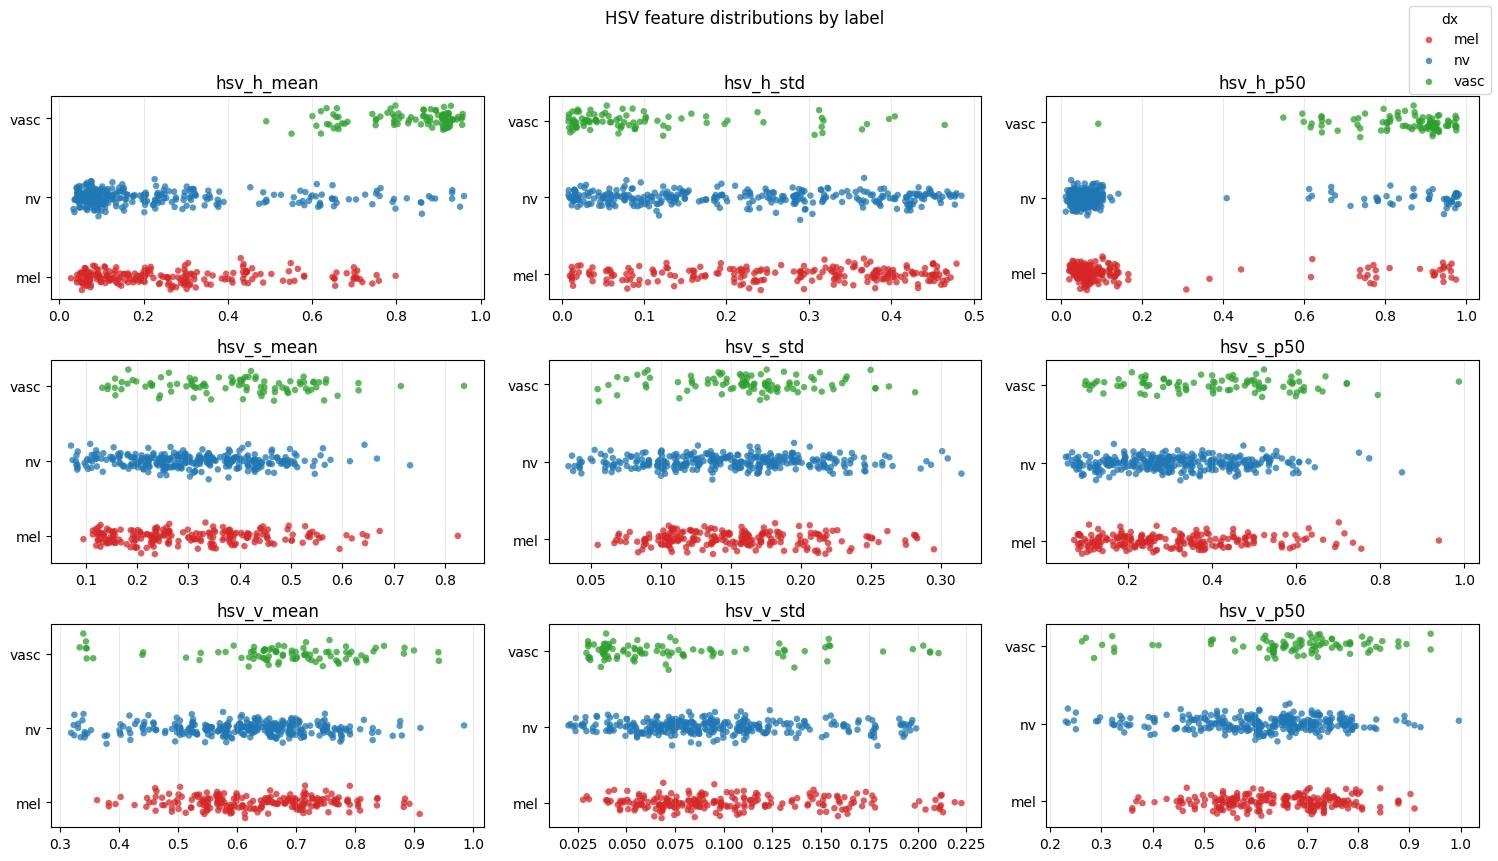

In [15]:
# test cell: hsv feature distributions by label
plot_feature_distribution_by_label(
    hsv_features,
    hsv_feature_names,
    labels,
    selected_features=hsv_feature_names,
    n_cols=3,
    title="HSV feature distributions by label",
)

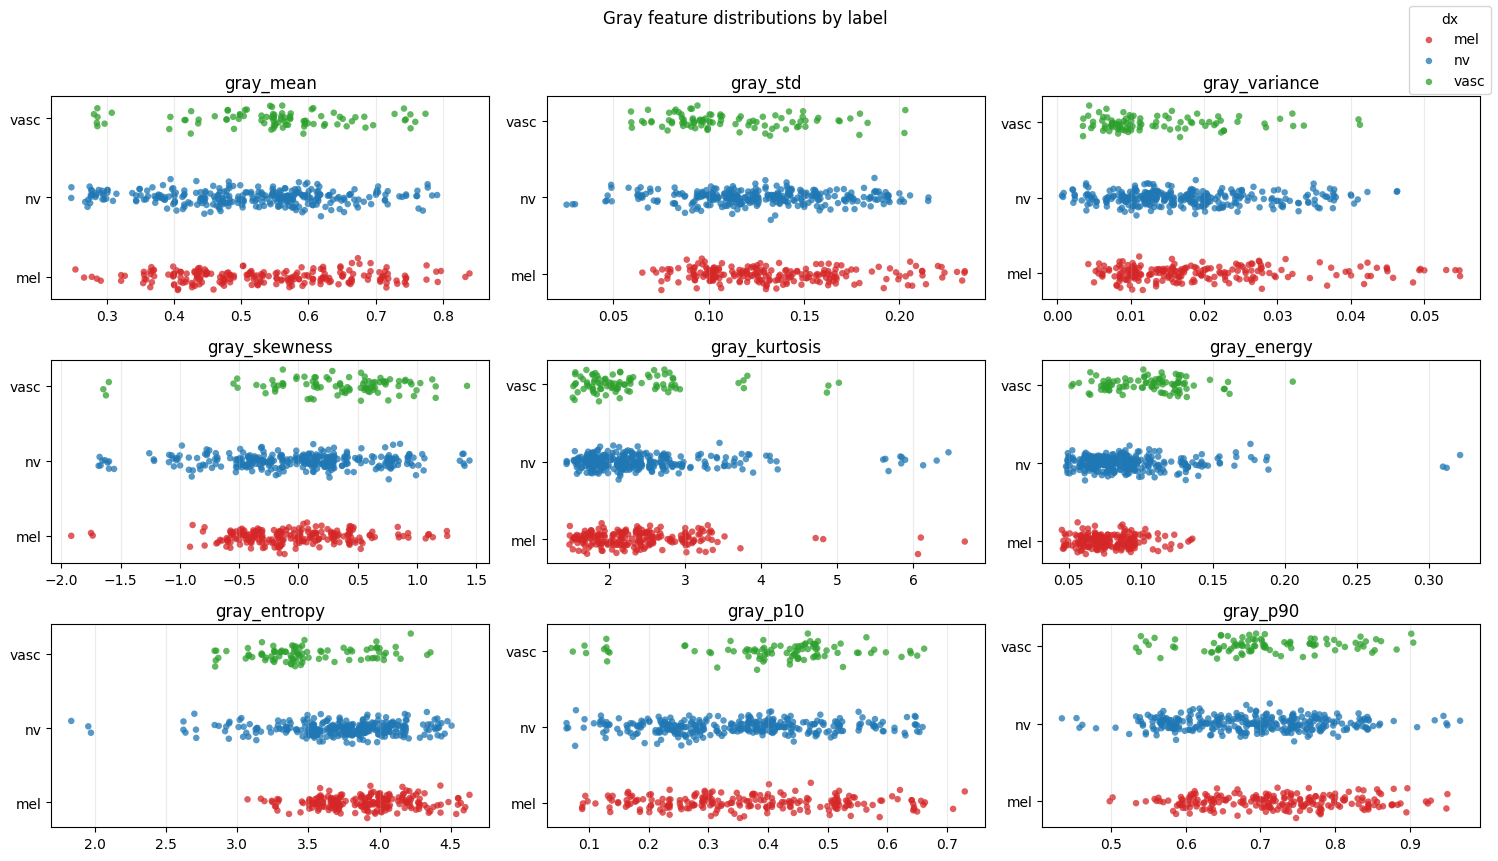

In [16]:
# test cell: gray feature distributions by label
plot_feature_distribution_by_label(
    gray_features,
    gray_feature_names,
    labels,
    selected_features=gray_feature_names,
    n_cols=3,
    title="Gray feature distributions by label",
)

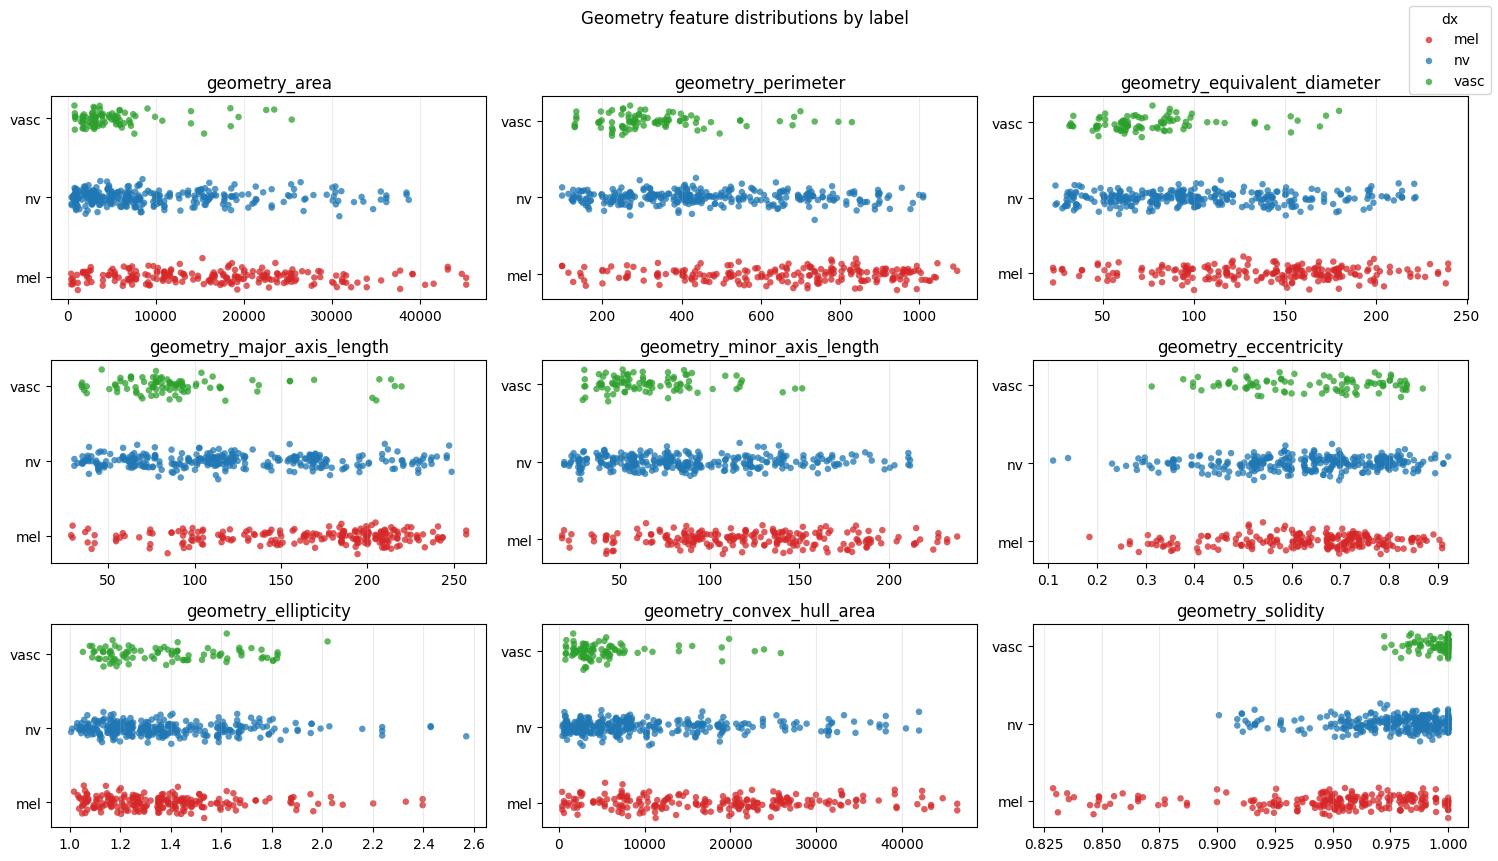

In [17]:
# test cell: geometry feature distributions by label
plot_feature_distribution_by_label(
    geometry_features,
    geometry_feature_names,
    labels,
    selected_features=geometry_feature_names,
    n_cols=3,
    title="Geometry feature distributions by label",
)

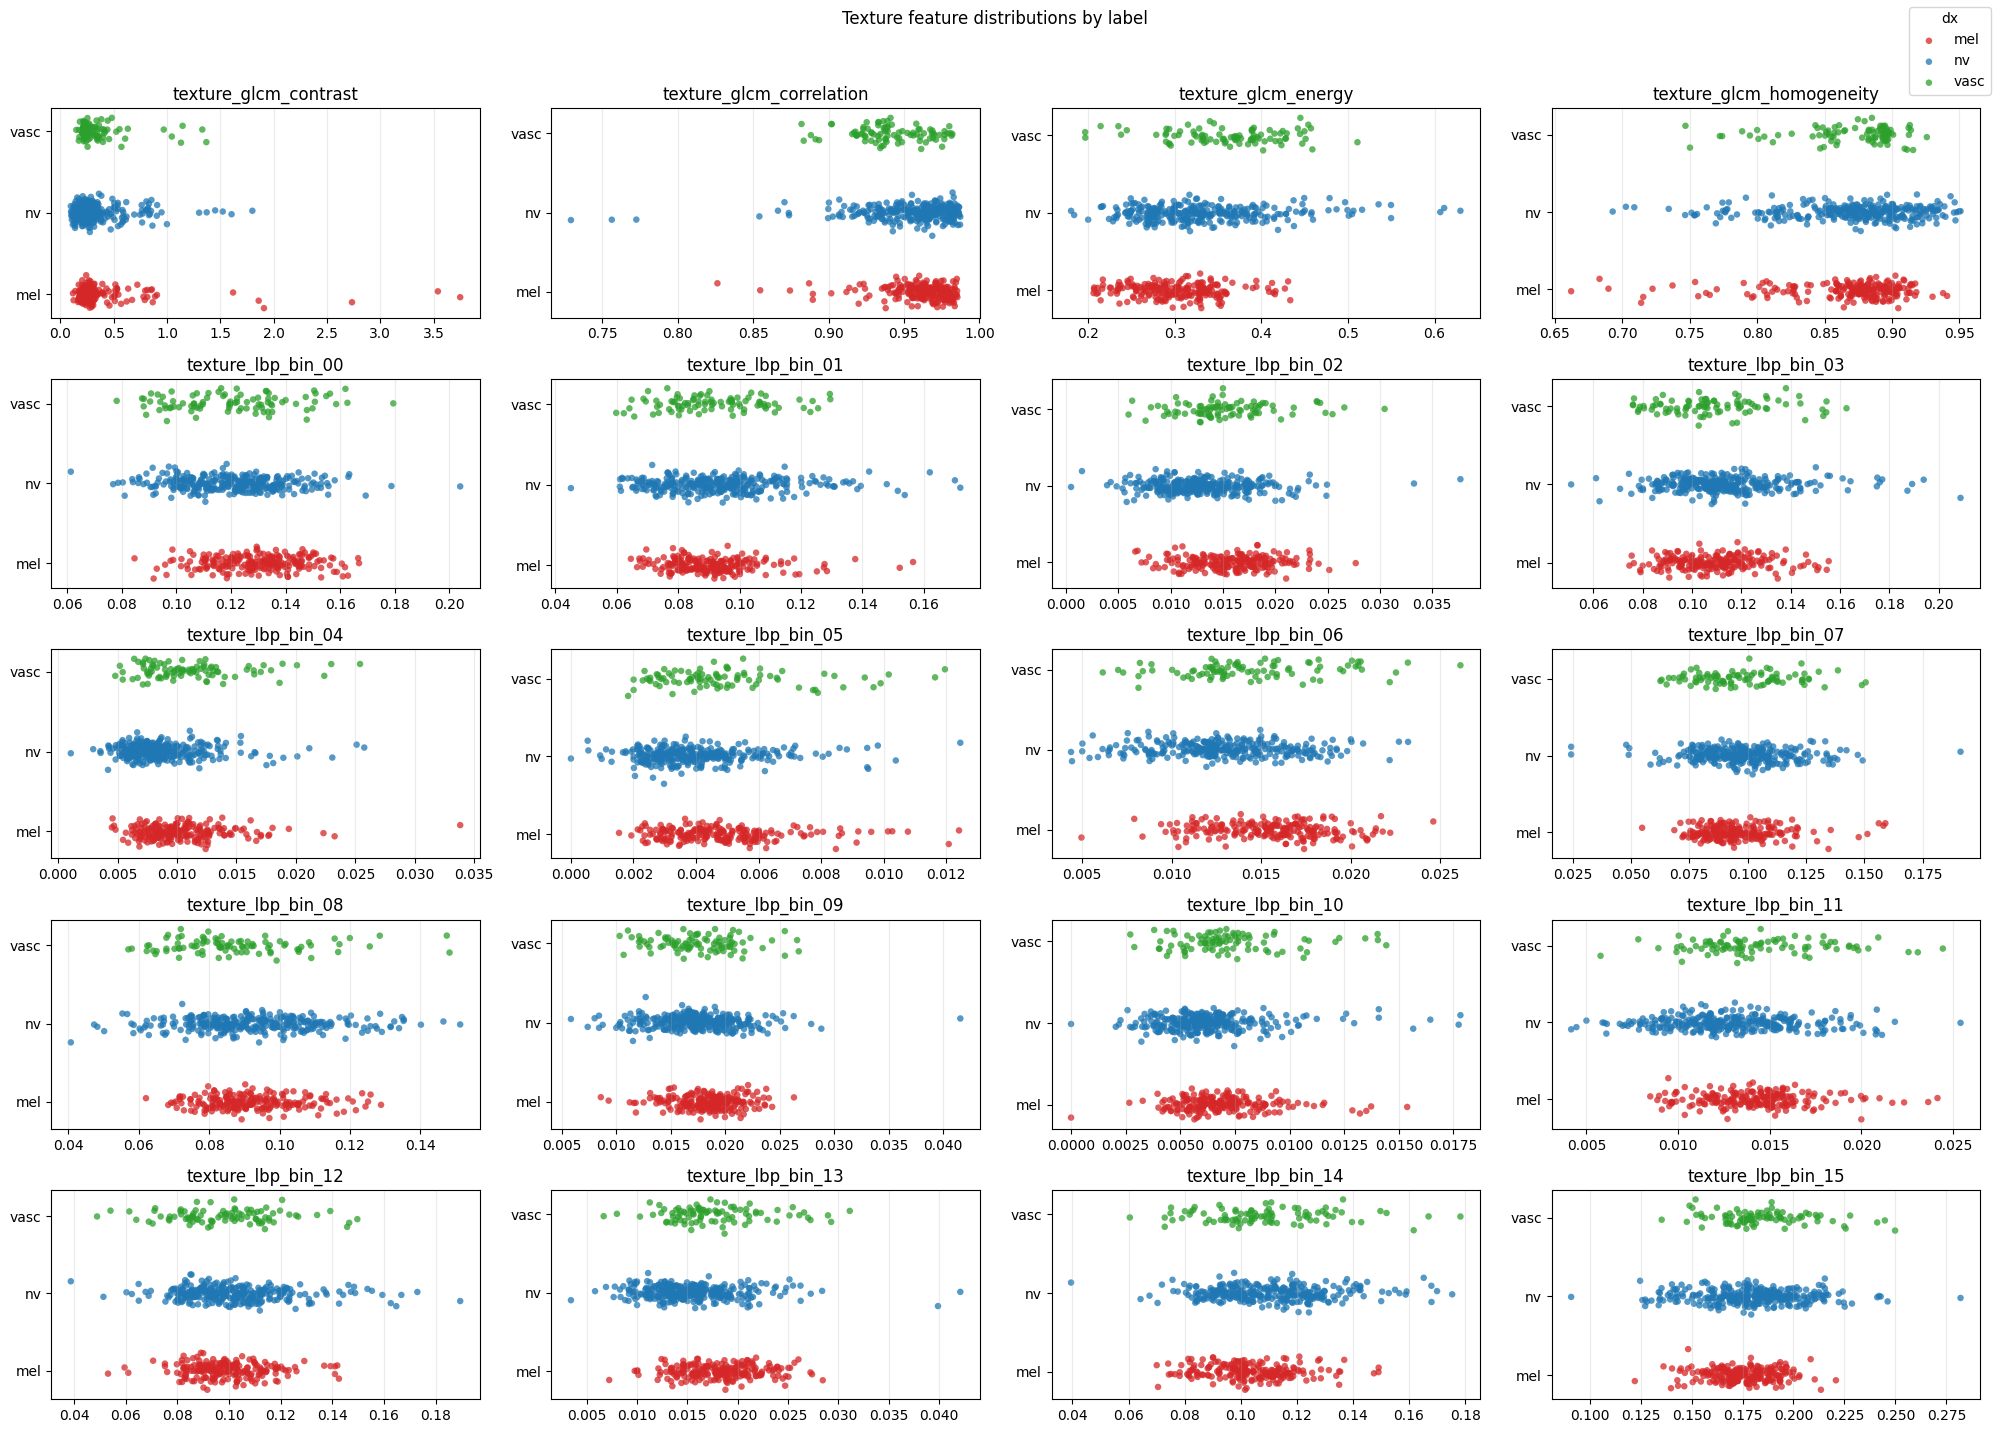

In [18]:
# test cell: texture feature distributions by label
plot_feature_distribution_by_label(
    texture_features,
    texture_feature_names,
    labels,
    selected_features=texture_feature_names,
    n_cols=4,
    title="Texture feature distributions by label",
)

### 2.3 Evaluation

- evaluate the effectiveness of features: **intra-group clustering** and **inter-group differences**.

In [19]:
# functions for feature evaluation: ANOVA F-statistic
def evaluate_features_anova(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
) -> dict[str, dict[str, float]]:
    """Evaluate each feature with one-way ANOVA F-statistic."""
    from sklearn.feature_selection import f_classif

    f_values, p_values = f_classif(features, labels)
    return {
        feature_name: {"anova_f": float(f_value), "anova_p": float(p_value)}
        for feature_name, f_value, p_value in zip(feature_names, f_values, p_values)
    }


In [20]:
# functions for feature evaluation: Mutual Information
def evaluate_features_mutual_information(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    random_state: int = 42,
) -> dict[str, float]:
    """Evaluate each feature with mutual information against class labels."""
    from sklearn.feature_selection import mutual_info_classif

    mi_values = mutual_info_classif(features, labels, random_state=random_state)
    return {
        feature_name: float(mi_value)
        for feature_name, mi_value in zip(feature_names, mi_values)
    }

In [21]:
# functions to combine and select features by evaluation scores
def combine_feature_evaluation_scores(
    feature_names: Sequence[str],
    anova_scores: dict[str, dict[str, float]],
    mutual_information_scores: dict[str, float],
) -> dict[str, dict[str, float]]:
    """Combine ANOVA and mutual-information scores in one dictionary."""
    return {
        feature_name: {
            "anova_f": anova_scores[feature_name]["anova_f"],
            "anova_p": anova_scores[feature_name]["anova_p"],
            "mutual_info": mutual_information_scores[feature_name],
        }
        for feature_name in feature_names
    }


def select_top_features_by_scores(
    evaluation_scores: dict[str, dict[str, float]],
    top_n: int = 10,
) -> list[str]:
    """Select features that appear in both ANOVA top_n and MI top_n rankings."""
    feature_names_sorted_by_anova = sorted(
        evaluation_scores,
        key=lambda feature_name: evaluation_scores[feature_name]["anova_f"],
        reverse=True,
    )
    feature_names_sorted_by_mi = sorted(
        evaluation_scores,
        key=lambda feature_name: evaluation_scores[feature_name]["mutual_info"],
        reverse=True,
    )

    top_anova = feature_names_sorted_by_anova[:top_n]
    top_mi = feature_names_sorted_by_mi[:top_n]
    top_mi_set = set(top_mi)
    selected = [feature_name for feature_name in top_anova if feature_name in top_mi_set]

    selected = sorted(
        selected,
        key=lambda feature_name: (
            feature_names_sorted_by_anova.index(feature_name)
            + feature_names_sorted_by_mi.index(feature_name)
        ),
    )
    return selected

In [22]:
# functions for show the images (add the evaluation values on the image display)
def show_feature_distribution_with_evaluation(
    features: np.ndarray,
    feature_names: Sequence[str],
    labels: Sequence[str],
    evaluation_scores: dict[str, dict[str, float]],
    selected_features: Sequence[str] | None = None,
    label_order: tuple[str, ...] = ("mel", "nv", "vasc"),
    colors: dict[str, str] | None = None,
    n_cols: int = 2,
    jitter: float = 0.08,
    point_size: int = 22,
    alpha: float = 0.75,
    random_state: int = 42,
    title: str = "Feature distribution with evaluation scores",
) -> None:
    """Show feature distributions and add ANOVA/MI values to each title."""
    labels_array = np.asarray(labels)
    colors = {"mel": "tab:red", "nv": "tab:blue", "vasc": "tab:green"} if colors is None else colors
    selected_features = list(feature_names) if selected_features is None else list(selected_features)
    feature_index = {feature_name: idx for idx, feature_name in enumerate(feature_names)}
    missing_features = [feature_name for feature_name in selected_features if feature_name not in feature_index]
    if missing_features:
        raise ValueError(f"Unknown selected features: {missing_features}")

    n_features = len(selected_features)
    n_rows = math.ceil(n_features / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.2 * n_rows), squeeze=False)
    rng = np.random.default_rng(random_state)
    label_to_y = {label_name: idx for idx, label_name in enumerate(label_order)}

    for ax, feature_name in zip(axes.ravel(), selected_features):
        values = features[:, feature_index[feature_name]]
        scores = evaluation_scores[feature_name]
        for label_name in label_order:
            idx = labels_array == label_name
            if not np.any(idx):
                continue
            y = np.full(idx.sum(), label_to_y[label_name], dtype=np.float32)
            y += rng.normal(0, jitter, size=idx.sum())
            ax.scatter(
                values[idx],
                y,
                color=colors.get(label_name, "gray"),
                s=point_size,
                alpha=alpha,
                label=label_name,
                edgecolors="none",
            )

        ax.set_title(
            f"{feature_name}\n"
            f"ANOVA F={scores['anova_f']:.3f}, MI={scores['mutual_info']:.3f}"
        )
        ax.set_xlabel("feature value")
        ax.set_yticks(list(label_to_y.values()), list(label_to_y.keys()))
        ax.grid(axis="x", alpha=0.25)

    for ax in axes.ravel()[n_features:]:
        ax.axis("off")

    handles, legend_labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, title="dx", loc="upper right")
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


In [23]:
# test
# perform ANOVA F-test and Mutual Information for each feature
# select features in the intersection of ANOVA top 10 and Mutual Information top 10
# show the images of selected features; the result may contain fewer than 10 features
anova_scores = evaluate_features_anova(features, labels, feature_names)
mutual_information_scores = evaluate_features_mutual_information(features, labels, feature_names)
evaluation_scores = combine_feature_evaluation_scores(
    feature_names,
    anova_scores,
    mutual_information_scores,
)

top_features = select_top_features_by_scores(
    evaluation_scores,
    top_n=10,
)

print(f"Selected {len(top_features)} features from ANOVA top 10 ∩ MI top 10:")
for feature_name in top_features:
    scores = evaluation_scores[feature_name]
    print(
        f"{feature_name}: "
        f"ANOVA F={scores['anova_f']:.4f}, "
        f"p={scores['anova_p']:.4e}, "
        f"MI={scores['mutual_info']:.4f}"
    )

Selected 9 features from ANOVA top 10 ∩ MI top 10:
hsv_h_mean: ANOVA F=293.8231, p=1.4525e-89, MI=0.3566
hsv_h_p50: ANOVA F=209.3764, p=1.2651e-69, MI=0.3641
geometry_solidity: ANOVA F=106.5440, p=2.7008e-40, MI=0.2789
geometry_major_axis_length: ANOVA F=66.4990, p=8.4493e-27, MI=0.2638
geometry_convex_hull_area: ANOVA F=62.4674, p=2.3265e-25, MI=0.2342
geometry_perimeter: ANOVA F=76.0768, p=3.7064e-30, MI=0.2149
geometry_equivalent_diameter: ANOVA F=60.3122, p=1.3900e-24, MI=0.2318
geometry_area: ANOVA F=57.0080, p=2.1996e-23, MI=0.2328
geometry_minor_axis_length: ANOVA F=56.5621, p=3.1992e-23, MI=0.1906


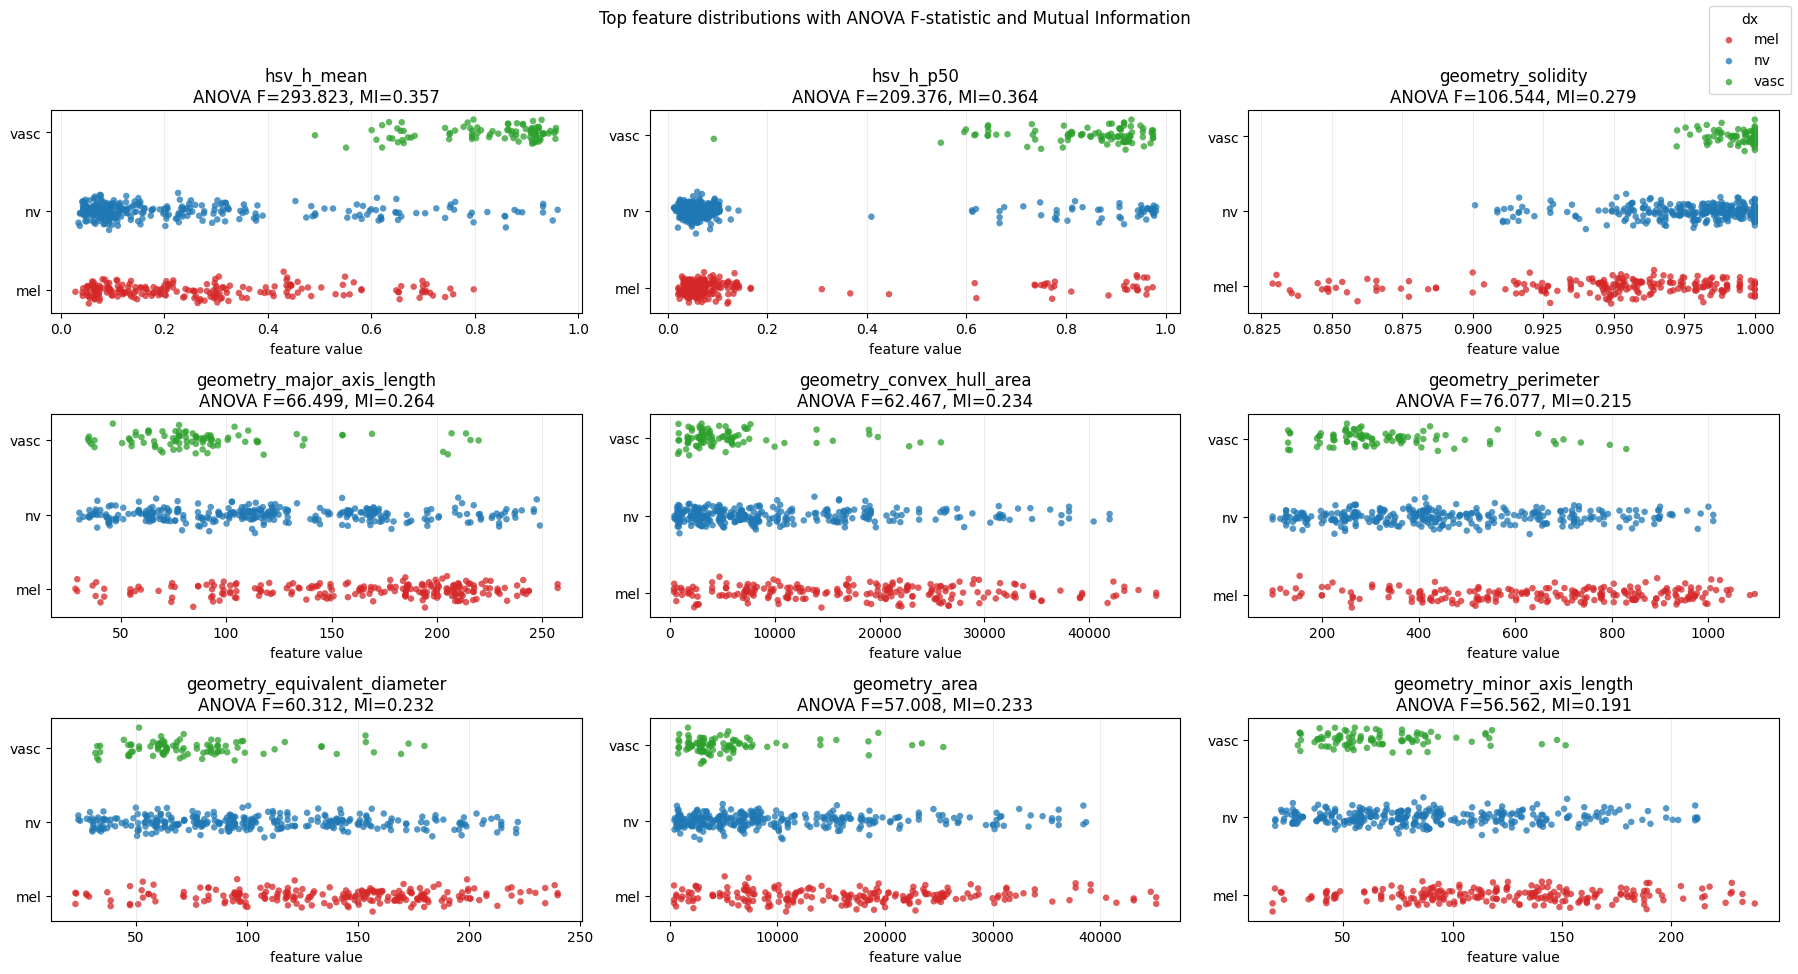

In [24]:
show_feature_distribution_with_evaluation(
    features,
    feature_names,
    labels,
    evaluation_scores,
    selected_features=top_features,
    n_cols=3,
    title="Top feature distributions with ANOVA F-statistic and Mutual Information",
)

## 3 Dimension Reduce

two part of attempts: PCA & UMAP

### 3.1 PCA

In [25]:
# Helper functions
def make_reduced_feature_names(prefix: str, n_components: int) -> list[str]:
    """Create names for reduced feature dimensions."""
    return [f"{prefix}_{idx + 1}" for idx in range(n_components)]


def format_pca_component(
    component_index: int,
    loadings: np.ndarray,
    feature_names: Sequence[str],
    max_terms: int | None = 10,
    coefficient_digits: int = 4,
) -> str:
    """Format one PCA component as a weighted sum of original features."""
    order = np.argsort(np.abs(loadings))[::-1]
    if max_terms is not None:
        order = order[:max_terms]

    terms = [
        f"{loadings[idx]:.{coefficient_digits}f} * {feature_names[idx]}"
        for idx in order
    ]
    suffix = "" if max_terms is None or max_terms >= len(feature_names) else " + ..."
    return f"{component_index + 1} Principal Component = " + " + ".join(terms) + suffix


def format_pca_components(
    pca_model,
    feature_names: Sequence[str],
    max_terms: int | None = 10,
    coefficient_digits: int = 4,
) -> list[str]:
    """Format all PCA components as readable weighted-sum strings."""
    return [
        format_pca_component(
            component_index=idx,
            loadings=component_loadings,
            feature_names=feature_names,
            max_terms=max_terms,
            coefficient_digits=coefficient_digits,
        )
        for idx, component_loadings in enumerate(pca_model.components_)
    ]


def evaluate_reduced_features(
    reduced_features: np.ndarray,
    labels: Sequence[str],
    reduced_feature_names: Sequence[str],
) -> dict[str, dict[str, float]]:
    """Evaluate reduced dimensions with the existing ANOVA and MI metrics."""
    anova_scores = evaluate_features_anova(reduced_features, labels, reduced_feature_names)
    mi_scores = evaluate_features_mutual_information(reduced_features, labels, reduced_feature_names)
    return combine_feature_evaluation_scores(reduced_feature_names, anova_scores, mi_scores)


def print_reduced_feature_evaluation(evaluation_scores: dict[str, dict[str, float]]) -> None:
    """Print evaluation values for each reduced dimension."""
    for feature_name, scores in evaluation_scores.items():
        print(
            f"{feature_name}: "
            f"ANOVA F={scores['anova_f']:.4f}, "
            f"p={scores['anova_p']:.4e}, "
            f"MI={scores['mutual_info']:.4f}"
        )


In [26]:
# Main function of PCA
def reduce_features_with_pca(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    n_components: int = 2,
    random_state: int = 42,
    max_component_terms: int | None = 10,
) -> dict[str, object]:
    """Reduce features with PCA and evaluate the reduced dimensions."""
    from sklearn.decomposition import PCA

    pca_model = PCA(n_components=n_components, random_state=random_state)
    reduced_features = pca_model.fit_transform(features)
    reduced_feature_names = make_reduced_feature_names("pca_component", n_components)
    component_descriptions = format_pca_components(
        pca_model,
        feature_names,
        max_terms=max_component_terms,
    )
    evaluation_scores = evaluate_reduced_features(
        reduced_features,
        labels,
        reduced_feature_names,
    )

    return {
        "features": reduced_features,
        "feature_names": reduced_feature_names,
        "model": pca_model,
        "component_descriptions": component_descriptions,
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "evaluation_scores": evaluation_scores,
    }


In [27]:
# test cell
pca_result = reduce_features_with_pca(
    features_scaled,
    labels,
    feature_names,
    n_components=10,
    max_component_terms=10,
)

pca_reduced_features = pca_result["features"]
print("PCA reduced dimension count:", pca_reduced_features.shape[1])
print("PCA explained variance ratio:", pca_result["explained_variance_ratio"])

print("\nPCA component composition:")
for component_description in pca_result["component_descriptions"]:
    print(component_description)

print("\nPCA reduced feature evaluation:")
print_reduced_feature_evaluation(pca_result["evaluation_scores"])


PCA reduced dimension count: 10
PCA explained variance ratio: [0.3038272  0.13186802 0.11356355 0.08851366 0.04622361 0.04061163
 0.03812813 0.0289773  0.02540228 0.02240185]

PCA component composition:
1 Principal Component = 0.2235 * gray_p10 + 0.2182 * gray_mean + 0.2130 * rgb_g_p10 + 0.2097 * rgb_b_p50 + 0.2094 * rgb_b_mean + 0.2072 * rgb_g_mean + 0.2013 * rgb_g_p50 + 0.1990 * rgb_r_p10 + 0.1946 * hsv_v_mean + 0.1937 * rgb_b_p10 + ...
2 Principal Component = 0.2808 * gray_entropy + 0.2621 * rgb_b_std + -0.2524 * gray_energy + -0.2310 * texture_glcm_energy + 0.2267 * gray_std + 0.2155 * gray_variance + 0.2090 * geometry_perimeter + 0.2065 * geometry_minor_axis_length + 0.2061 * geometry_equivalent_diameter + 0.2048 * geometry_convex_hull_area + ...
3 Principal Component = 0.2693 * texture_glcm_homogeneity + -0.2522 * texture_lbp_bin_04 + -0.2448 * texture_glcm_contrast + 0.2381 * geometry_equivalent_diameter + 0.2334 * geometry_major_axis_length + 0.2331 * geometry_minor_axis_length

In [28]:
# evaluate functions according to the label classes
def compute_label_dimension_values(
    reduced_features: np.ndarray,
    labels: Sequence[str],
    reduced_feature_names: Sequence[str],
    label_order: tuple[str, ...] = ("mel", "nv", "vasc"),
) -> dict[str, dict[str, dict[str, float]]]:
    """Compute each label's mean/std value on every reduced dimension."""
    labels_array = np.asarray(labels)
    label_dimension_values: dict[str, dict[str, dict[str, float]]] = {}

    for label_name in label_order:
        label_mask = labels_array == label_name
        label_features = reduced_features[label_mask]
        label_dimension_values[label_name] = {}
        for dimension_index, dimension_name in enumerate(reduced_feature_names):
            dimension_values = label_features[:, dimension_index]
            label_dimension_values[label_name][dimension_name] = {
                "mean": float(dimension_values.mean()),
                "std": float(dimension_values.std()),
            }

    return label_dimension_values


def label_dimension_values_to_centroids(
    label_dimension_values: dict[str, dict[str, dict[str, float]]],
    reduced_feature_names: Sequence[str],
    label_order: tuple[str, ...] = ("mel", "nv", "vasc"),
) -> tuple[np.ndarray, list[str]]:
    """Convert label dimension values to centroid matrix for prediction."""
    centroids = []
    centroid_labels = []
    for label_name in label_order:
        if label_name not in label_dimension_values:
            continue
        centroids.append([
            label_dimension_values[label_name][dimension_name]["mean"]
            for dimension_name in reduced_feature_names
        ])
        centroid_labels.append(label_name)

    return np.asarray(centroids, dtype=np.float32), centroid_labels


def predict_labels_by_nearest_centroid(
    reduced_features: np.ndarray,
    centroids: np.ndarray,
    centroid_labels: Sequence[str],
) -> list[str]:
    """Predict labels by nearest centroid in reduced feature space."""
    distances = np.linalg.norm(
        reduced_features[:, None, :] - centroids[None, :, :],
        axis=2,
    )
    nearest_indices = np.argmin(distances, axis=1)
    return [centroid_labels[index] for index in nearest_indices]


def calculate_hit_rate(
    predicted_labels: Sequence[str],
    true_labels: Sequence[str],
) -> float:
    """Calculate prediction hit rate against true labels."""
    predicted_array = np.asarray(predicted_labels)
    true_array = np.asarray(true_labels)
    return float(np.mean(predicted_array == true_array))


def evaluate_reduced_features_by_label_centroids(
    reduced_features: np.ndarray,
    labels: Sequence[str],
    reduced_feature_names: Sequence[str],
    label_order: tuple[str, ...] = ("mel", "nv", "vasc"),
) -> dict[str, object]:
    """Evaluate reduced features by label centroids and hit rate."""
    label_dimension_values = compute_label_dimension_values(
        reduced_features,
        labels,
        reduced_feature_names,
        label_order=label_order,
    )
    centroids, centroid_labels = label_dimension_values_to_centroids(
        label_dimension_values,
        reduced_feature_names,
        label_order=label_order,
    )
    predicted_labels = predict_labels_by_nearest_centroid(
        reduced_features,
        centroids,
        centroid_labels,
    )
    hit_rate = calculate_hit_rate(predicted_labels, labels)

    return {
        "label_dimension_values": label_dimension_values,
        "centroids": centroids,
        "centroid_labels": centroid_labels,
        "predicted_labels": predicted_labels,
        "hit_rate": hit_rate,
    }


def print_label_dimension_values(
    label_dimension_values: dict[str, dict[str, dict[str, float]]],
) -> None:
    """Print each label's value on every reduced dimension."""
    for label_name, dimension_values in label_dimension_values.items():
        print(f"{label_name}:")
        for dimension_name, stats in dimension_values.items():
            print(
                f"  {dimension_name}: "
                f"mean={stats['mean']:.4f}, "
                f"std={stats['std']:.4f}"
            )


def print_hit_rate_summary(
    method_name: str,
    hit_rate: float,
    sample_count: int,
) -> None:
    """Print hit-rate summary for a dimension-reduction method."""
    hit_count = int(round(hit_rate * sample_count))
    print(f"{method_name} hit rate: {hit_rate:.4f} ({hit_count}/{sample_count})")


pca_label_evaluation = evaluate_reduced_features_by_label_centroids(
    pca_result["features"],
    labels,
    pca_result["feature_names"],
)

# print("PCA label values on each component:")
# print_label_dimension_values(pca_label_evaluation["label_dimension_values"])
# print()
print_hit_rate_summary(
    "PCA nearest-centroid prediction",
    pca_label_evaluation["hit_rate"],
    len(labels),
)


PCA nearest-centroid prediction hit rate: 0.6433 (386/600)


#### Test

In [29]:
# test cell
pca_result = reduce_features_with_pca(
    features_scaled,
    labels,
    feature_names,
    n_components=3,
    max_component_terms=10,
)

pca_reduced_features = pca_result["features"]
print("PCA reduced dimension count:", pca_reduced_features.shape[1])
print("PCA explained variance ratio:", pca_result["explained_variance_ratio"])


pca_label_evaluation = evaluate_reduced_features_by_label_centroids(
    pca_result["features"],
    labels,
    pca_result["feature_names"],
)
print_hit_rate_summary(
    "PCA nearest-centroid prediction",
    pca_label_evaluation["hit_rate"],
    len(labels),
)


PCA reduced dimension count: 3
PCA explained variance ratio: [0.30382726 0.13186793 0.11356352]
PCA nearest-centroid prediction hit rate: 0.5433 (326/600)


#### Optimize

In [30]:
# optimize the parameters of PCA
def optimize_pca_parameters(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    n_components_options: Sequence[int] = (2, 3, 5, 8, 10, 15),
    whiten_options: Sequence[bool] = (False, True),
    max_component_terms: int | None = 10,
    random_state: int = 42,
) -> dict[str, object]:
    """Search PCA parameters and select the setting with the best hit rate."""
    from itertools import product
    from sklearn.decomposition import PCA

    best_result: dict[str, object] | None = None
    search_records: list[dict[str, object]] = []
    max_components = min(features.shape[0], features.shape[1])

    for n_components, whiten in product(n_components_options, whiten_options):
        if n_components > max_components:
            continue

        pca_model = PCA(
            n_components=n_components,
            whiten=whiten,
            random_state=random_state,
        )
        reduced_features = pca_model.fit_transform(features)
        reduced_feature_names = make_reduced_feature_names("pca_component", n_components)
        label_evaluation = evaluate_reduced_features_by_label_centroids(
            reduced_features,
            labels,
            reduced_feature_names,
        )
        hit_rate = label_evaluation["hit_rate"]
        params = {"n_components": n_components, "whiten": whiten}
        record = {
            "params": params,
            "hit_rate": hit_rate,
            "features": reduced_features,
            "feature_names": reduced_feature_names,
            "model": pca_model,
            "label_evaluation": label_evaluation,
            "explained_variance_ratio": pca_model.explained_variance_ratio_,
            "component_descriptions": format_pca_components(
                pca_model,
                feature_names,
                max_terms=max_component_terms,
            ),
        }
        search_records.append(record)

        if best_result is None or hit_rate > best_result["hit_rate"]:
            best_result = record

    return {"best_result": best_result, "search_records": search_records}


def print_pca_optimization_result(optimization_result: dict[str, object]) -> None:
    """Print best PCA parameters and hit rate."""
    best_result = optimization_result["best_result"]
    print("Best PCA parameters:", best_result["params"])
    print("Best PCA hit rate:", f"{best_result['hit_rate']:.4f}")
    print("Explained variance ratio:", best_result["explained_variance_ratio"])


# test cell for PCA parameter optimization
pca_optimization_result = optimize_pca_parameters(
    features_scaled,
    labels,
    feature_names,
    n_components_options=(2, 3, 5, 8, 10, 15, 20),
    whiten_options=(False, True),
    max_component_terms=10,
)
print_pca_optimization_result(pca_optimization_result)


Best PCA parameters: {'n_components': 20, 'whiten': True}
Best PCA hit rate: 0.7683
Explained variance ratio: [0.30382738 0.13186805 0.11356357 0.08851367 0.04622357 0.04061161
 0.03812814 0.02897734 0.02540231 0.02240188 0.02214574 0.01731059
 0.01468828 0.01339312 0.01029701 0.00956897 0.0079917  0.00786677
 0.00613195 0.00570306]


### 3.2 UMAP

In [31]:
# Helper functions
def make_umap_reducer(
    n_components: int = 2,
    n_neighbors: int = 20,
    min_dist: float = 0.1,
    metric: str = "euclidean",
    random_state: int = 42,
):
    """Create a configured UMAP reducer."""
    from umap import UMAP

    return UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )


In [32]:
# Main functions of UMAP
def reduce_features_with_umap(
    features: np.ndarray,
    labels: Sequence[str],
    n_components: int = 2,
    n_neighbors: int = 20,
    min_dist: float = 0.1,
    metric: str = "euclidean",
    random_state: int = 42,
) -> dict[str, object]:
    """Reduce features with UMAP and evaluate the reduced dimensions."""
    reducer = make_umap_reducer(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    reduced_features = reducer.fit_transform(features)
    reduced_feature_names = make_reduced_feature_names("umap_dimension", n_components)
    evaluation_scores = evaluate_reduced_features(
        reduced_features,
        labels,
        reduced_feature_names,
    )

    return {
        "features": reduced_features,
        "feature_names": reduced_feature_names,
        "model": reducer,
        "evaluation_scores": evaluation_scores,
    }


In [33]:
# test cell
umap_result = reduce_features_with_umap(
    features_scaled,
    labels,
    n_components=10,
    n_neighbors=20,
    min_dist=0.1,
)

umap_reduced_features = umap_result["features"]
print("UMAP reduced dimension count:", umap_reduced_features.shape[1])

print("\nUMAP reduced feature evaluation:")
print_reduced_feature_evaluation(umap_result["evaluation_scores"])


/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced dimension count: 10

UMAP reduced feature evaluation:
umap_dimension_1: ANOVA F=211.7688, p=3.1108e-70, MI=0.2922
umap_dimension_2: ANOVA F=23.3218, p=1.7687e-10, MI=0.2139
umap_dimension_3: ANOVA F=6.6749, p=1.3585e-03, MI=0.1455
umap_dimension_4: ANOVA F=52.7820, p=7.8088e-22, MI=0.2577
umap_dimension_5: ANOVA F=95.6001, p=9.6016e-37, MI=0.2830
umap_dimension_6: ANOVA F=33.1298, p=2.2688e-14, MI=0.2231
umap_dimension_7: ANOVA F=23.5337, p=1.4532e-10, MI=0.2109
umap_dimension_8: ANOVA F=28.2665, p=1.8663e-12, MI=0.0786
umap_dimension_9: ANOVA F=43.9806, p=1.5208e-18, MI=0.1314
umap_dimension_10: ANOVA F=14.8377, p=5.1418e-07, MI=0.0512


In [34]:
# evaluate functions according to the label classes
umap_label_evaluation = evaluate_reduced_features_by_label_centroids(
    umap_result["features"],
    labels,
    umap_result["feature_names"],
)

print("UMAP label values on each dimension:")
print_label_dimension_values(umap_label_evaluation["label_dimension_values"])
print()
print_hit_rate_summary(
    "UMAP nearest-centroid prediction",
    umap_label_evaluation["hit_rate"],
    len(labels),
)


UMAP label values on each dimension:
mel:
  umap_dimension_1: mean=2.8160, std=0.7355
  umap_dimension_2: mean=10.4237, std=1.0743
  umap_dimension_3: mean=6.5183, std=0.7246
  umap_dimension_4: mean=4.7306, std=0.4319
  umap_dimension_5: mean=2.7498, std=0.4796
  umap_dimension_6: mean=4.3358, std=0.4089
  umap_dimension_7: mean=5.4863, std=0.9198
  umap_dimension_8: mean=5.0545, std=0.3276
  umap_dimension_9: mean=6.6808, std=0.5721
  umap_dimension_10: mean=6.1333, std=0.3058
nv:
  umap_dimension_1: mean=3.2015, std=0.7089
  umap_dimension_2: mean=10.8058, std=0.9910
  umap_dimension_3: mean=6.6634, std=0.7344
  umap_dimension_4: mean=4.6620, std=0.4722
  umap_dimension_5: mean=3.1280, std=0.5938
  umap_dimension_6: mean=4.1634, std=0.4304
  umap_dimension_7: mean=5.8732, std=0.8736
  umap_dimension_8: mean=4.9417, std=0.3898
  umap_dimension_9: mean=6.4564, std=0.5117
  umap_dimension_10: mean=6.2510, std=0.3295
vasc:
  umap_dimension_1: mean=4.7624, std=0.9449
  umap_dimension_2: 

#### Test

In [35]:
# test cell
umap_result = reduce_features_with_umap(
    features_scaled,
    labels,
    n_components=3,
    n_neighbors=10,
    min_dist=0.001,
)

umap_reduced_features = umap_result["features"]
print("UMAP reduced dimension count:", umap_reduced_features.shape[1])
print()
# evaluate functions according to the label classes
umap_label_evaluation = evaluate_reduced_features_by_label_centroids(
    umap_result["features"],
    labels,
    umap_result["feature_names"],
)

print_hit_rate_summary(
    "UMAP nearest-centroid prediction",
    umap_label_evaluation["hit_rate"],
    len(labels),
)


/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced dimension count: 3

UMAP nearest-centroid prediction hit rate: 0.5950 (357/600)


#### Optimize

In [36]:
# optimize the parameters of UMAP
def optimize_umap_parameters(
    features: np.ndarray,
    labels: Sequence[str],
    n_components_options: Sequence[int] = (2, 3, 5, 8, 10),
    n_neighbors_options: Sequence[int] = (5, 10, 20, 30),
    min_dist_options: Sequence[float] = (0.001, 0.01, 0.1, 0.3),
    metric_options: Sequence[str] = ("euclidean",),
    random_state: int = 42,
) -> dict[str, object]:
    """Search UMAP parameters and select the setting with the best hit rate."""
    from itertools import product

    best_result: dict[str, object] | None = None
    search_records: list[dict[str, object]] = []

    for n_components, n_neighbors, min_dist, metric in product(
        n_components_options,
        n_neighbors_options,
        min_dist_options,
        metric_options,
    ):
        reducer = make_umap_reducer(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            random_state=random_state,
        )
        reduced_features = reducer.fit_transform(features)
        reduced_feature_names = make_reduced_feature_names("umap_dimension", n_components)
        label_evaluation = evaluate_reduced_features_by_label_centroids(
            reduced_features,
            labels,
            reduced_feature_names,
        )
        hit_rate = label_evaluation["hit_rate"]
        params = {
            "n_components": n_components,
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "metric": metric,
        }
        record = {
            "params": params,
            "hit_rate": hit_rate,
            "features": reduced_features,
            "feature_names": reduced_feature_names,
            "model": reducer,
            "label_evaluation": label_evaluation,
        }
        search_records.append(record)

        if best_result is None or hit_rate > best_result["hit_rate"]:
            best_result = record

        print(f"UMAP params {params} -> hit rate {hit_rate:.4f}")

    return {"best_result": best_result, "search_records": search_records}


def print_umap_optimization_result(optimization_result: dict[str, object]) -> None:
    """Print best UMAP parameters and hit rate."""
    best_result = optimization_result["best_result"]
    print("Best UMAP parameters:", best_result["params"])
    print("Best UMAP hit rate:", f"{best_result['hit_rate']:.4f}")


# test cell for UMAP parameter optimization
# This grid is intentionally compact because UMAP fitting can be slow.
umap_optimization_result = optimize_umap_parameters(
    features_scaled,
    labels,
    n_components_options=(2, 3, 5, 8),
    n_neighbors_options=(5, 10, 20),
    min_dist_options=(0.001, 0.01, 0.1),
    metric_options=("euclidean",),
    random_state=42,
)
print_umap_optimization_result(umap_optimization_result)


/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP params {'n_components': 2, 'n_neighbors': 5, 'min_dist': 0.001, 'metric': 'euclidean'} -> hit rate 0.4817


/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP params {'n_components': 2, 'n_neighbors': 5, 'min_dist': 0.01, 'metric': 'euclidean'} -> hit rate 0.4467


/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

UMAP params {'n_components': 8, 'n_neighbors': 20, 'min_dist': 0.001, 'metric': 'euclidean'} -> hit rate 0.5883


/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP params {'n_components': 8, 'n_neighbors': 20, 'min_dist': 0.01, 'metric': 'euclidean'} -> hit rate 0.5883


/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP params {'n_components': 8, 'n_neighbors': 20, 'min_dist': 0.1, 'metric': 'euclidean'} -> hit rate 0.5867
Best UMAP parameters: {'n_components': 5, 'n_neighbors': 5, 'min_dist': 0.01, 'metric': 'euclidean'}
Best UMAP hit rate: 0.6567


## 4 Random Forest

### 4.1 Splitting the Training and Test Sets

In [37]:
# Helper function: Splitting the Training and Test Sets
def split_random_forest_dataset(
    features: np.ndarray,
    labels: Sequence[str],
    test_size: float = 0.2,
    random_state: int = 42,
    stratify: bool = True,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Split features and labels into training and test sets."""
    from sklearn.model_selection import train_test_split

    labels_array = np.asarray(labels)
    stratify_labels = labels_array if stratify else None
    return train_test_split(
        features,
        labels_array,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_labels,
    )


def get_random_forest_feature_importance(
    model,
    feature_names: Sequence[str],
) -> list[tuple[str, float]]:
    """Return feature importances sorted from high to low."""
    importance_pairs = [
        (feature_name, float(importance))
        for feature_name, importance in zip(feature_names, model.feature_importances_)
    ]
    return sorted(importance_pairs, key=lambda item: item[1], reverse=True)


def print_top_random_forest_features(
    feature_importances: Sequence[tuple[str, float]],
    top_n: int = 15,
) -> None:
    """Print top random-forest feature importances."""
    print(f"Top {min(top_n, len(feature_importances))} Random Forest feature importances:")
    for feature_name, importance in feature_importances[:top_n]:
        print(f"{feature_name}: {importance:.6f}")


### 4.2 Building and Training Models

In [38]:
# Main function: Building and Training Models
def build_random_forest_classifier(
    n_estimators: int = 500,
    max_depth: int | None = None,
    min_samples_leaf: int = 2,
    class_weight: str | dict[str, float] | None = "balanced",
    random_state: int = 42,
):
    """Create a Random Forest classifier."""
    from sklearn.ensemble import RandomForestClassifier

    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=-1,
    )


def train_random_forest_model(
    x_train: np.ndarray,
    y_train: Sequence[str],
    n_estimators: int = 500,
    max_depth: int | None = None,
    min_samples_leaf: int = 2,
    class_weight: str | dict[str, float] | None = "balanced",
    random_state: int = 42,
):
    """Build and train a Random Forest classifier."""
    model = build_random_forest_classifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=random_state,
    )
    model.fit(x_train, y_train)
    return model


def run_random_forest_training_pipeline(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    test_size: float = 0.2,
    split_random_state: int = 42,
    model_random_state: int = 42,
    n_estimators: int = 500,
    max_depth: int | None = None,
    min_samples_leaf: int = 2,
) -> dict[str, object]:
    """Split data, train Random Forest, and collect feature importances."""
    x_train, x_test, y_train, y_test = split_random_forest_dataset(
        features,
        labels,
        test_size=test_size,
        random_state=split_random_state,
        stratify=True,
    )
    model = train_random_forest_model(
        x_train,
        y_train,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=model_random_state,
    )
    feature_importances = get_random_forest_feature_importance(model, feature_names)

    return {
        "model": model,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "feature_importances": feature_importances,
    }


### 4.3 Prediction and Assessment

In [39]:
# Test function: Prediction and Assessment
def predict_with_random_forest(model, x_test: np.ndarray) -> np.ndarray:
    """Predict labels for test features."""
    return model.predict(x_test)


def evaluate_random_forest_predictions(
    y_true: Sequence[str],
    y_pred: Sequence[str],
    label_order: tuple[str, ...] = ("mel", "nv", "vasc"),
) -> dict[str, object]:
    """Evaluate Random Forest predictions with accuracy and confusion matrix."""
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    accuracy = float(accuracy_score(y_true, y_pred))
    matrix = confusion_matrix(y_true, y_pred, labels=list(label_order))
    report = classification_report(
        y_true,
        y_pred,
        labels=list(label_order),
        zero_division=0,
    )
    return {
        "accuracy": accuracy,
        "hit_rate": accuracy,
        "confusion_matrix": matrix,
        "classification_report": report,
        "label_order": label_order,
    }


def print_random_forest_evaluation(evaluation: dict[str, object]) -> None:
    """Print Random Forest evaluation results."""
    print(f"Random Forest hit rate: {evaluation['hit_rate']:.4f}")
    print("Label order:", evaluation["label_order"])
    print("Confusion matrix:")
    print(evaluation["confusion_matrix"])
    print("Classification report:")
    print(evaluation["classification_report"])


def run_random_forest_prediction_assessment(
    model,
    x_test: np.ndarray,
    y_test: Sequence[str],
    label_order: tuple[str, ...] = ("mel", "nv", "vasc"),
) -> dict[str, object]:
    """Predict on test set and evaluate the result."""
    y_pred = predict_with_random_forest(model, x_test)
    evaluation = evaluate_random_forest_predictions(y_test, y_pred, label_order=label_order)
    evaluation["y_pred"] = y_pred
    return evaluation


### 4.4 Test

In [40]:
# test cell 
# Random Forest can use raw tabular feature values. features_scaled also works,
# but tree-based models usually do not require feature standardization.
random_forest_result = run_random_forest_training_pipeline(
    features,
    labels,
    feature_names,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
)

random_forest_evaluation = run_random_forest_prediction_assessment(
    random_forest_result["model"],
    random_forest_result["x_test"],
    random_forest_result["y_test"],
)

print_random_forest_evaluation(random_forest_evaluation)
print()
print_top_random_forest_features(
    random_forest_result["feature_importances"],
    top_n=20,
)


Random Forest hit rate: 0.8778
Label order: ('mel', 'nv', 'vasc')
Confusion matrix:
[[44 19  0]
 [ 1 89  0]
 [ 0  2 25]]
Classification report:
              precision    recall  f1-score   support

         mel       0.98      0.70      0.81        63
          nv       0.81      0.99      0.89        90
        vasc       1.00      0.93      0.96        27

    accuracy                           0.88       180
   macro avg       0.93      0.87      0.89       180
weighted avg       0.90      0.88      0.87       180


Top 20 Random Forest feature importances:
hsv_h_mean: 0.098163
hsv_h_p50: 0.082075
geometry_solidity: 0.061568
hsv_h_std: 0.032582
geometry_convex_hull_area: 0.031647
rgb_b_std: 0.030427
geometry_perimeter: 0.023766
gray_entropy: 0.022994
geometry_major_axis_length: 0.022769
geometry_area: 0.021807
geometry_equivalent_diameter: 0.021000
gray_energy: 0.018783
geometry_minor_axis_length: 0.018678
rgb_b_p10: 0.018398
texture_lbp_bin_06: 0.017867
hsv_v_std: 0.016495
texture

### 4.5 Parameter Optimization

In [41]:
# fucntions of optimizing the hyperparameters
def get_default_random_forest_param_distributions() -> dict[str, list[object]]:
    """Return a compact default search space for Random Forest tuning."""
    return {
        "n_estimators": [100, 200, 300, 500, 800],
        "max_depth": [None, 5, 8, 12, 16, 24],
        "min_samples_leaf": [1, 2, 3, 4, 6, 8],
        "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    }


def build_random_forest_for_search(random_state: int = 42):
    """Create the base Random Forest model used by search methods."""
    from sklearn.ensemble import RandomForestClassifier

    return RandomForestClassifier(
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1,
    )


def optimize_random_forest_random_search(
    x_train: np.ndarray,
    y_train: Sequence[str],
    param_distributions: dict[str, list[object]] | None = None,
    n_iter: int = 40,
    cv: int = 5,
    scoring: str = "accuracy",
    random_state: int = 42,
) -> dict[str, object]:
    """Optimize Random Forest hyperparameters with randomized search."""
    from sklearn.model_selection import RandomizedSearchCV

    param_distributions = (
        get_default_random_forest_param_distributions()
        if param_distributions is None
        else param_distributions
    )
    search = RandomizedSearchCV(
        estimator=build_random_forest_for_search(random_state=random_state),
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        random_state=random_state,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    search.fit(x_train, y_train)
    return {
        "search": search,
        "best_model": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
    }


def optimize_random_forest_grid_search(
    x_train: np.ndarray,
    y_train: Sequence[str],
    param_grid: dict[str, list[object]],
    cv: int = 5,
    scoring: str = "accuracy",
    random_state: int = 42,
) -> dict[str, object]:
    """Optimize Random Forest hyperparameters with grid search."""
    from sklearn.model_selection import GridSearchCV

    search = GridSearchCV(
        estimator=build_random_forest_for_search(random_state=random_state),
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    search.fit(x_train, y_train)
    return {
        "search": search,
        "best_model": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
    }


def print_random_forest_optimization_result(optimization_result: dict[str, object]) -> None:
    """Print best hyperparameters and cross-validation score."""
    print("Best CV score:", f"{optimization_result['best_cv_score']:.4f}")
    print("Best parameters:")
    for param_name, param_value in optimization_result["best_params"].items():
        print(f"- {param_name}: {param_value}")


def evaluate_optimized_random_forest(
    optimization_result: dict[str, object],
    x_test: np.ndarray,
    y_test: Sequence[str],
    feature_names: Sequence[str],
    top_n_features: int = 20,
) -> dict[str, object]:
    """Evaluate the optimized Random Forest on the held-out test set."""
    best_model = optimization_result["best_model"]
    evaluation = run_random_forest_prediction_assessment(best_model, x_test, y_test)
    feature_importances = get_random_forest_feature_importance(best_model, feature_names)
    print_random_forest_optimization_result(optimization_result)
    print()
    print_random_forest_evaluation(evaluation)
    print()
    print_top_random_forest_features(feature_importances, top_n=top_n_features)
    return {
        "evaluation": evaluation,
        "feature_importances": feature_importances,
    }


In [42]:
# test cell 
# Step 1: split once and tune only on the training set.
x_train_opt, x_test_opt, y_train_opt, y_test_opt = split_random_forest_dataset(
    features,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

# Step 2: random search over core parameters. Increase n_iter for a deeper search.
rf_optimization_result = optimize_random_forest_random_search(
    x_train_opt,
    y_train_opt,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
)

# Step 3: evaluate best model on the held-out test set.
rf_optimized_test_result = evaluate_optimized_random_forest(
    rf_optimization_result,
    x_test_opt,
    y_test_opt,
    feature_names,
    top_n_features=20,
)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV score: 0.8762
Best parameters:
- n_estimators: 100
- min_samples_leaf: 2
- max_features: sqrt
- max_depth: 8

Random Forest hit rate: 0.8722
Label order: ('mel', 'nv', 'vasc')
Confusion matrix:
[[46 17  0]
 [ 5 85  0]
 [ 0  1 26]]
Classification report:
              precision    recall  f1-score   support

         mel       0.90      0.73      0.81        63
          nv       0.83      0.94      0.88        90
        vasc       1.00      0.96      0.98        27

    accuracy                           0.87       180
   macro avg       0.91      0.88      0.89       180
weighted avg       0.88      0.87      0.87       180


Top 20 Random Forest feature importances:
hsv_h_mean: 0.105810
hsv_h_p50: 0.079081
geometry_solidity: 0.059652
rgb_b_std: 0.034219
hsv_h_std: 0.028810
geometry_convex_hull_area: 0.027897
geometry_area: 0.025692
geometry_perimeter: 0.025661
geometry_equivalent_diameter: 0.022499
gray_entropy: 0

- change the parameter `scoring` 

In [43]:
# test cell 
# Step 1: split once and tune only on the training set.
x_train_opt, x_test_opt, y_train_opt, y_test_opt = split_random_forest_dataset(
    features,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

# Step 2: random search over core parameters. Increase n_iter for a deeper search.
rf_optimization_result = optimize_random_forest_random_search(
    x_train_opt,
    y_train_opt,
    n_iter=30,
    cv=5,
    scoring="recall_macro",
    random_state=42,
)

# Step 3: evaluate best model on the held-out test set.
rf_optimized_test_result = evaluate_optimized_random_forest(
    rf_optimization_result,
    x_test_opt,
    y_test_opt,
    feature_names,
    top_n_features=20,
)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV score: 0.8735
Best parameters:
- n_estimators: 100
- min_samples_leaf: 2
- max_features: sqrt
- max_depth: 8

Random Forest hit rate: 0.8722
Label order: ('mel', 'nv', 'vasc')
Confusion matrix:
[[46 17  0]
 [ 5 85  0]
 [ 0  1 26]]
Classification report:
              precision    recall  f1-score   support

         mel       0.90      0.73      0.81        63
          nv       0.83      0.94      0.88        90
        vasc       1.00      0.96      0.98        27

    accuracy                           0.87       180
   macro avg       0.91      0.88      0.89       180
weighted avg       0.88      0.87      0.87       180


Top 20 Random Forest feature importances:
hsv_h_mean: 0.105810
hsv_h_p50: 0.079081
geometry_solidity: 0.059652
rgb_b_std: 0.034219
hsv_h_std: 0.028810
geometry_convex_hull_area: 0.027897
geometry_area: 0.025692
geometry_perimeter: 0.025661
geometry_equivalent_diameter: 0.022499
gray_entropy: 0

In [ ]:
# test cell 
# Step 1: split once and tune only on the training set.
x_train_opt, x_test_opt, y_train_opt, y_test_opt = split_random_forest_dataset(
    features,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

# Step 2: random search over core parameters. Increase n_iter for a deeper search.
rf_optimization_result = optimize_random_forest_random_search(
    x_train_opt,
    y_train_opt,
    n_iter=30,
    cv=5,
    scoring="f1_macro",
    random_state=42,
)

# Step 3: evaluate best model on the held-out test set.
rf_optimized_test_result = evaluate_optimized_random_forest(
    rf_optimization_result,
    x_test_opt,
    y_test_opt,
    feature_names,
    top_n_features=20,
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV score: 0.8823
Best parameters:
- n_estimators: 100
- min_samples_leaf: 2
- max_features: sqrt
- max_depth: 8

Random Forest hit rate: 0.8722
Label order: ('mel', 'nv', 'vasc')
Confusion matrix:
[[46 17  0]
 [ 5 85  0]
 [ 0  1 26]]
Classification report:
              precision    recall  f1-score   support

         mel       0.90      0.73      0.81        63
          nv       0.83      0.94      0.88        90
        vasc       1.00      0.96      0.98        27

    accuracy                           0.87       180
   macro avg       0.91      0.88      0.89       180
weighted avg       0.88      0.87      0.87       180


Top 20 Random Forest feature importances:
hsv_h_mean: 0.105810
hsv_h_p50: 0.079081
geometry_solidity: 0.059652
rgb_b_std: 0.034219
hsv_h_std: 0.028810
geometry_convex_hull_area: 0.027897
geometry_area: 0.025692
geometry_perimeter: 0.025661
geometry_equivalent_diameter: 0.022499
gray_entropy: 0